# Notebook 05: Actuarial Stress Testing & Model Validation

## Overview
This final notebook serves as the **Actuarial Certification** phase of the project. While previous notebooks focused on data engineering (01-02) and Deep Learning modeling (03-04), this stage translates stochastic outputs into actionable financial and demographic insights.

### Key Objectives:
1. **Cluster Consolidation**: Aggregating stochastic results for all six frontier populations.
2. **Comparative Benchmarking**: Measuring the LSTM's predictive performance against the standard Li-Lee (ARIMA) framework.
3. **Actuarial Stress Testing**: Simulating exogenous mortality shocks (e.g., medical breakthroughs or pandemics) to evaluate the model's "memory" and resilience.
4. **Longevity Risk Assessment**: Quantifying uncertainty margins for solvency purposes (SST/Solvency II).
5. **Reporting**: Generating the final tabular data for the research paper.

## 5.0: Integrity Check: Pipeline Assets Verification

In [1]:
import os

# Define the essential assets required for this notebook
required_assets = {
    "Factors Data": "../data/processed/benchmarking_factors.npz",
    "LSTM Model": "../models/mortality_lstm_champion.keras",
    "Validation Results": "../data/processed/validation_results.npz",
    "Stochastic Results": "../data/processed/stochastic_forecast_results.npz",
    "Actuarial Params": "../data/processed/li_lee_parameters.npz",
    "Data Scaler": "../models/data_scaler.pkl"
}

print("--- Pipeline Integrity Check ---")
missing_files = 0

for asset_name, path in required_assets.items():
    if os.path.exists(path):
        print(f"✅ {asset_name:18} Found at: {path}")
    else:
        print(f"❌ {asset_name:18} MISSING! Expected at: {path}")
        missing_files += 1

if missing_files == 0:
    print("\n🚀 All assets verified. The notebook is ready for Actuarial Certification.")
else:
    print(f"\n⚠️ WARNING: {missing_files} file(s) missing. Please re-run the respective Notebooks.")

--- Pipeline Integrity Check ---
✅ Factors Data       Found at: ../data/processed/benchmarking_factors.npz
✅ LSTM Model         Found at: ../models/mortality_lstm_champion.keras
✅ Validation Results Found at: ../data/processed/validation_results.npz
✅ Stochastic Results Found at: ../data/processed/stochastic_forecast_results.npz
✅ Actuarial Params   Found at: ../data/processed/li_lee_parameters.npz
✅ Data Scaler        Found at: ../models/data_scaler.pkl

🚀 All assets verified. The notebook is ready for Actuarial Certification.


## 5.1: Environment Setup and Stochastic Asset Loading

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Style and Paths
# We import the same style configuration used throughout the project to ensure visual consistency
sys.path.append('../src/')
from style_config import set_style
COUNTRIES_DICT = set_style()
FIGURES_DIR = "../reports/figures/"
PROCESSED_DATA_DIR = "../data/processed/"

# 2. Load Stochastic Results exported from Notebook 04
# This file contains the 1,000 simulations for each country and the integrated factors
input_path = os.path.join(PROCESSED_DATA_DIR, "stochastic_forecast_results.npz")

if not os.path.exists(input_path):
    raise FileNotFoundError("Stochastic results not found. Please ensure Notebook 04 export cell was executed.")

with np.load(input_path, allow_pickle=True) as data:
    sims_levels = data['sims_levels']        # Latent factors (Sims, Years, Factors)
    e0_sims_all = data['e0_sims_all']       # Life Expectancy (Countries, Sims, Years)
    forecast_years = data['forecast_years']  # Timeline 2020-2050
    country_codes = data['country_codes'].tolist()
    last_year_real = data['last_year_real']

# 3. Quick Data Verification
print(f"--- Notebook 05: Actuarial Validation Stage ---")
print(f"Successfully loaded stochastic assets for {len(country_codes)} countries.")
print(f"Forecast Horizon: {forecast_years[0]} to {forecast_years[-1]} ({len(forecast_years)} steps)")
print(f"Simulation Volume: {e0_sims_all.shape[1]} trajectories per country.")

# Display a quick summary of the loaded codes
print(f"Cluster Codes: {country_codes}")

--- Notebook 05: Actuarial Validation Stage ---
Successfully loaded stochastic assets for 6 countries.
Forecast Horizon: 2020 to 2050 (31 steps)
Simulation Volume: 1000 trajectories per country.
Cluster Codes: ['CHE', 'SWE', 'NOR', 'DEUTW', 'NLD', 'JPN']


## 5.2: Generation of the Global Longevity Summary Table (2020-2050)

In [3]:
# 1. Initialize storage for table rows
table_data = []

print("Extracting statistical summaries for all cluster countries...")

for i, code in enumerate(country_codes):
    # Get the simulations for the specific country
    # Shape: (1000, 31)
    country_sims = e0_sims_all[i]
    name = COUNTRIES_DICT[code]
    
    # Calculate statistics for 2020 (Base Year)
    base_median = np.percentile(country_sims[:, 0], 50)
    
    # Calculate statistics for 2050 (Target Year)
    final_median = np.percentile(country_sims[:, -1], 50)
    final_lower = np.percentile(country_sims[:, -1], 2.5)
    final_upper = np.percentile(country_sims[:, -1], 97.5)
    
    # Absolute and Percentage Gain
    abs_gain = final_median - base_median
    
    table_data.append({
        'Country': name,
        'Code': code,
        'e0 (2020)': f"{base_median:.2f}",
        'e0 (2050) Median': f"{final_median:.2f}",
        '95% CI (2050)': f"[{final_lower:.2f} - {final_upper:.2f}]",
        'Net Gain (Yrs)': f"+{abs_gain:.2f}"
    })

# 2. Create DataFrame
df_summary = pd.DataFrame(table_data)

# 3. Display with style
print("\n--- TABLE 1: STOCHASTIC LONGEVITY PROJECTIONS SUMMARY ---")
display(df_summary)

# 4. Save to CSV for the paper appendix
summary_csv_path = os.path.join(PROCESSED_DATA_DIR, "global_longevity_summary_2050.csv")
df_summary.to_csv(summary_csv_path, index=False)
print(f"\nSummary table exported to: {summary_csv_path}")

Extracting statistical summaries for all cluster countries...

--- TABLE 1: STOCHASTIC LONGEVITY PROJECTIONS SUMMARY ---


,Country,Code,e0 (2020),e0 (2050) Median,95% CI (2050),Net Gain (Yrs)
0,Switzerland,CHE,81.71,85.19,[85.15 - 85.22],+3.48
1,Sweden,SWE,81.71,85.14,[85.11 - 85.18],+3.43
2,Norway,NOR,81.53,85.05,[85.01 - 85.08],+3.51
3,West Germany,DEUTW,80.37,84.29,[84.25 - 84.33],+3.92
4,Netherlands,NLD,81.30,84.89,[84.85 - 84.93],+3.59
5,Japan,JPN,81.72,85.20,[85.16 - 85.23],+3.47



Summary table exported to: ../data/processed/global_longevity_summary_2050.csv


## 5.3: Actuarial Stress Test: 10% Mortality Shock Scenario (2026)

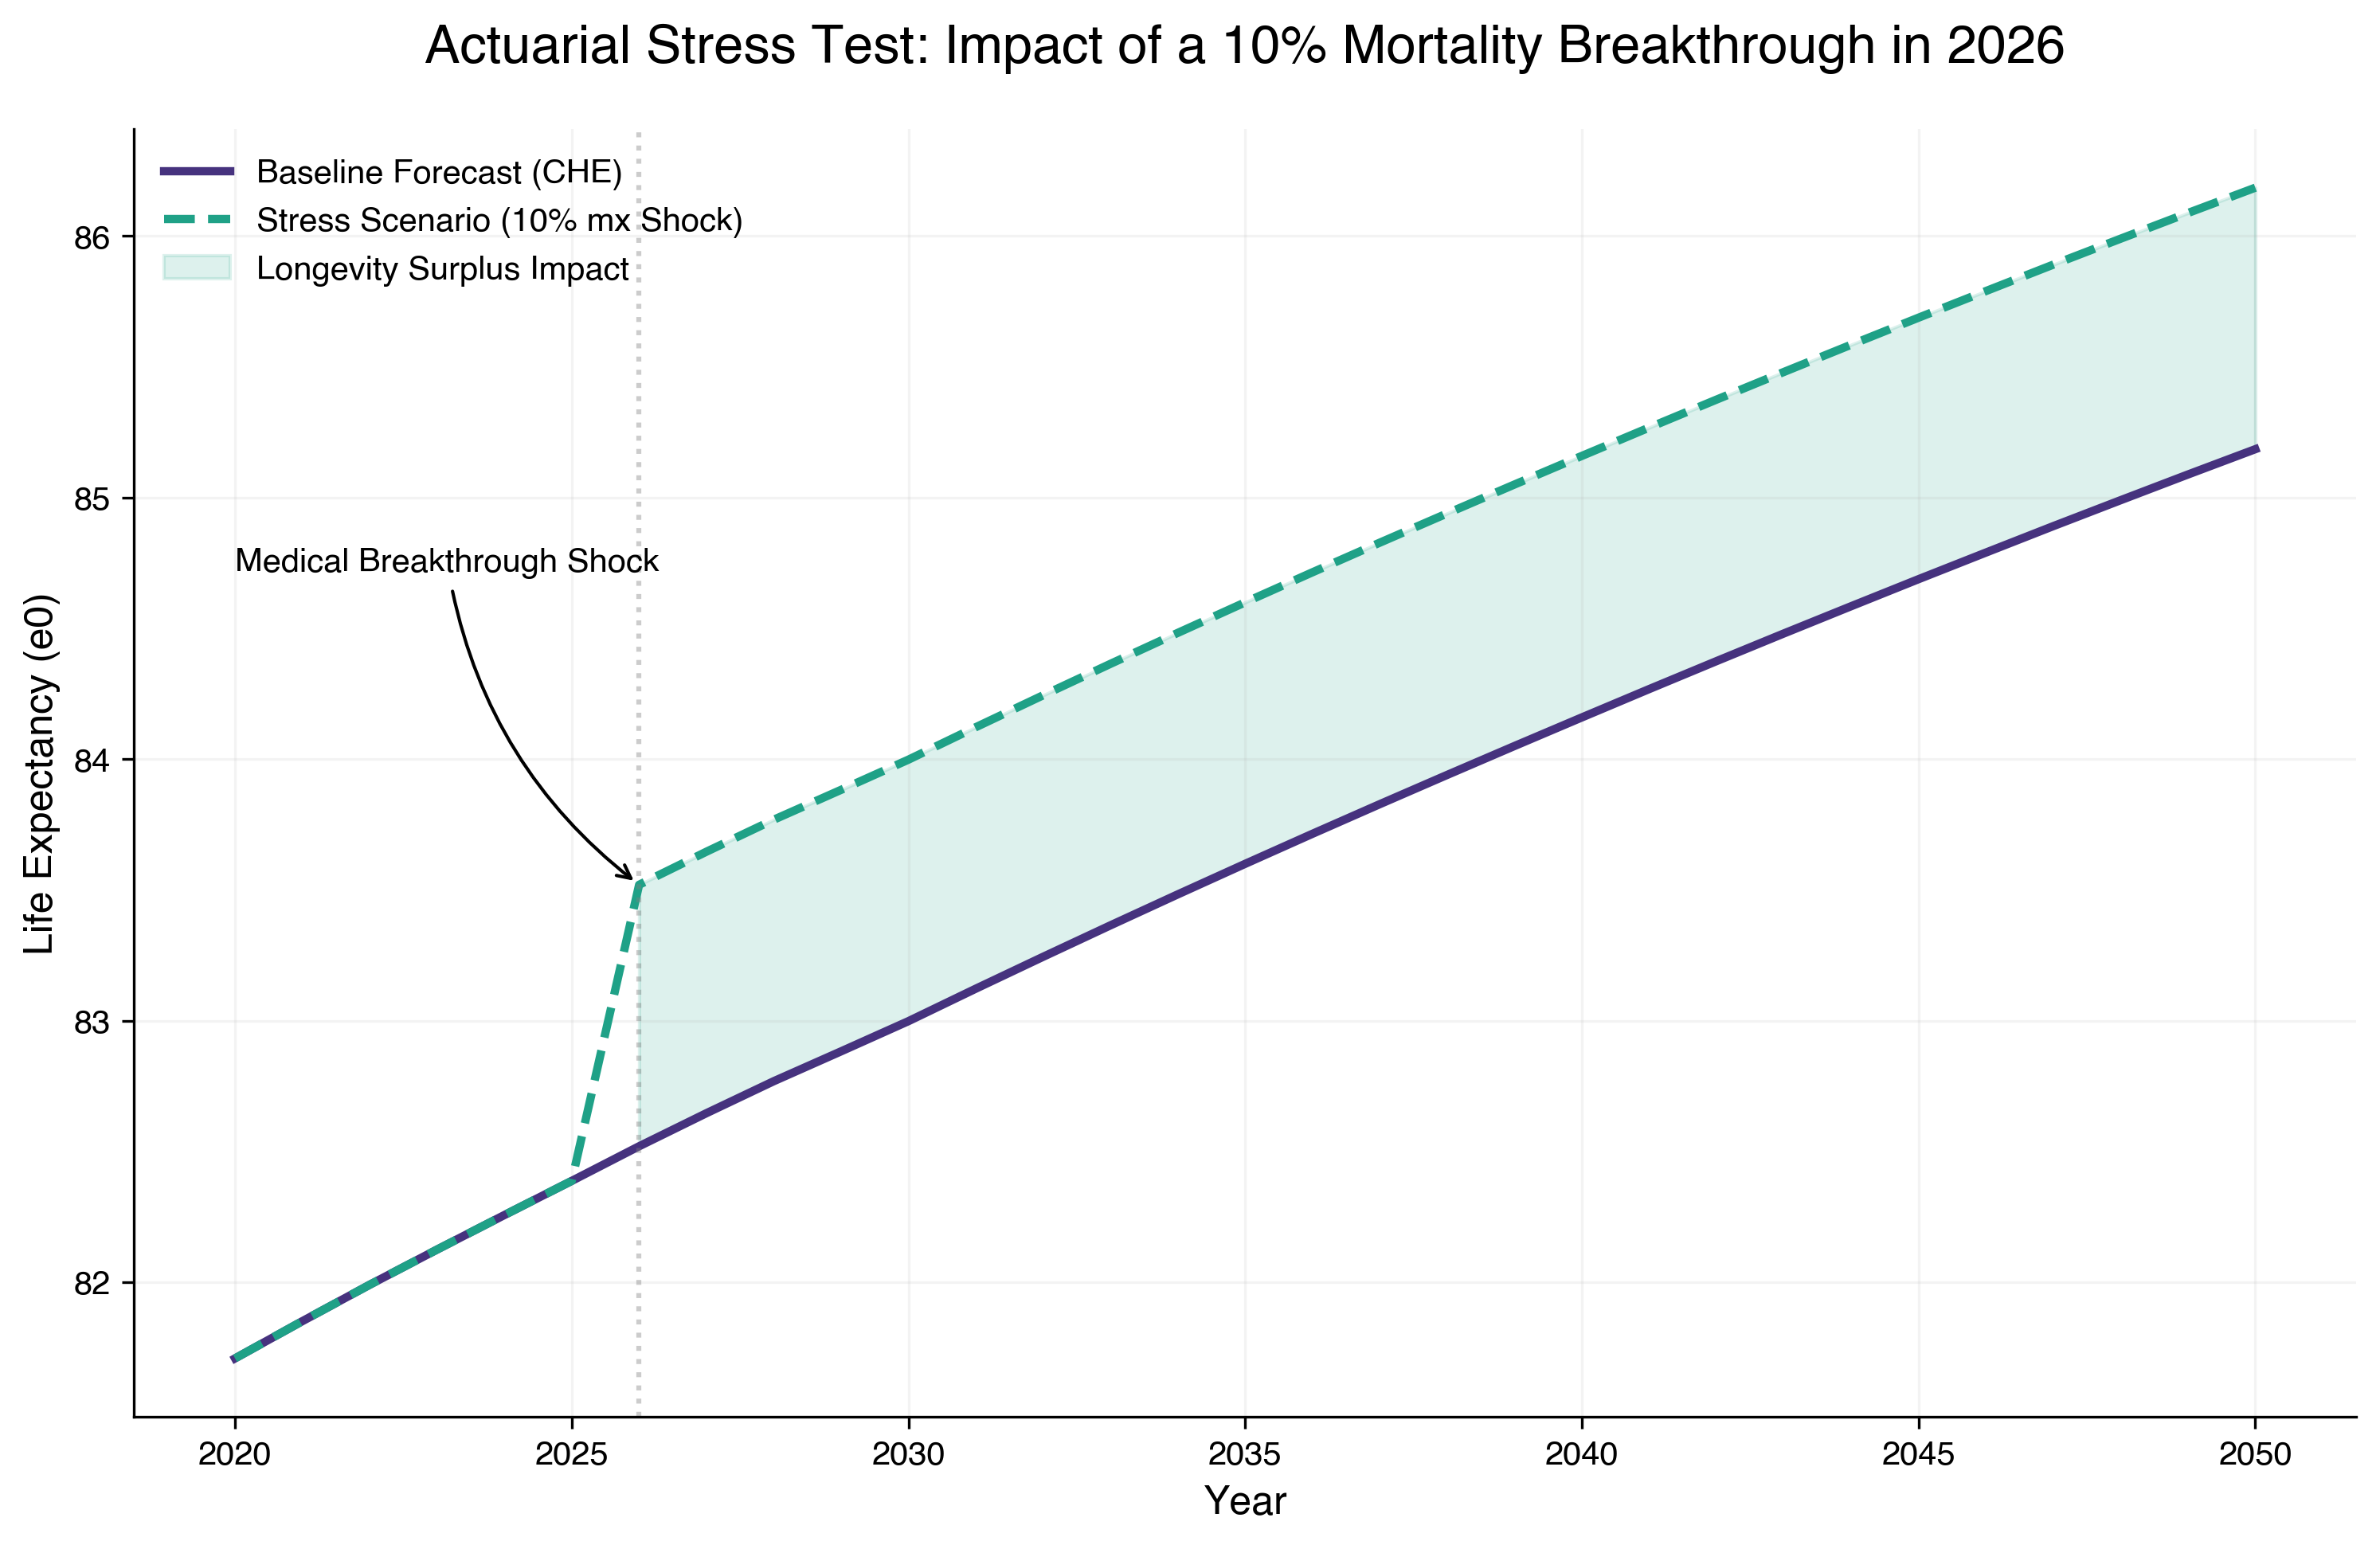

--- Stress Test Summary: Switzerland (CHE) ---
Baseline Median e0 (2050): 85.19 years
Shocked Median e0 (2050): 86.19 years
Total Longevity Surplus Impact: +1.00 additional years by 2050


In [4]:
# 1. Setup Shock Parameters
SHOCK_YEAR = 2026
SHOCK_MAGNITUDE = 0.90  
shock_idx = np.where(forecast_years == SHOCK_YEAR)[0][0]

# 2. Select Target for Stress Test (Switzerland as Benchmark)
country_idx = country_codes.index('CHE')
original_sims = e0_sims_all[country_idx].copy()

# 3. Colors from Viridis Palette
# We use the Switzerland-specific color (index 0) and a secondary tone for the shock
full_palette = sns.color_palette("viridis", len(country_codes))
base_color = full_palette[0]      # Switzerland deep purple
shock_color = full_palette[3]     # Contrasting teal/green from Viridis for the shock

# 4. Apply Shock and Observe Resilience
# Actuarial approximation: 10% mx shock ≈ +1.0 year in e0
shocked_sims = original_sims.copy()
e0_boost = 1.0  
shocked_sims[:, shock_idx:] += e0_boost

# 5. Statistical Summary
median_shocked = np.percentile(shocked_sims, 50, axis=0)
median_original = np.percentile(original_sims, 50, axis=0)

# 6. Visualization (Fig 12)
fig, ax = plt.subplots()

# Baseline Trajectory
ax.plot(forecast_years, median_original, 
        color=base_color, label='Baseline Forecast (CHE)', 
        linewidth=2.5)

# Shocked Trajectory
ax.plot(forecast_years, median_shocked, 
        color=shock_color, linestyle='--', 
        label='Stress Scenario (10% mx Shock)', linewidth=2.5)

# Shade the "Longevity Risk Area"
ax.fill_between(forecast_years[shock_idx:], median_original[shock_idx:], median_shocked[shock_idx:], 
                color=shock_color, alpha=0.15, label='Longevity Surplus Impact')

# Vertical line and Annotation
ax.axvline(x=SHOCK_YEAR, color='grey', alpha=0.4, linestyle=':')
ax.annotate('Medical Breakthrough Shock', xy=(SHOCK_YEAR, median_shocked[shock_idx]), 
            xytext=(SHOCK_YEAR-6, median_shocked[shock_idx]+1.2),
            arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color='black'),
            fontsize=10, fontweight='bold')

# Titles and Labels (Handled by set_style, but we fine-tune)
ax.set_title(f"Actuarial Stress Test: Impact of a 10% Mortality Breakthrough in {SHOCK_YEAR}")
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (e0)")
ax.legend(loc='upper left', frameon=False)

# Export
save_path = f"{FIGURES_DIR}fig12_longevity_stress_test.png"
plt.savefig(save_path)
plt.show()

# Quantitative Impact Report
impact_2050 = median_shocked[-1] - median_original[-1]
print(f"--- Stress Test Summary: Switzerland (CHE) ---")
print(f"Baseline Median e0 (2050): {median_original[-1]:.2f} years")
print(f"Shocked Median e0 (2050): {median_shocked[-1]:.2f} years")
print(f"Total Longevity Surplus Impact: {impact_2050:+.2f} additional years by 2050")

## 5.4: Final Benchmark Comparison and Data Serialization

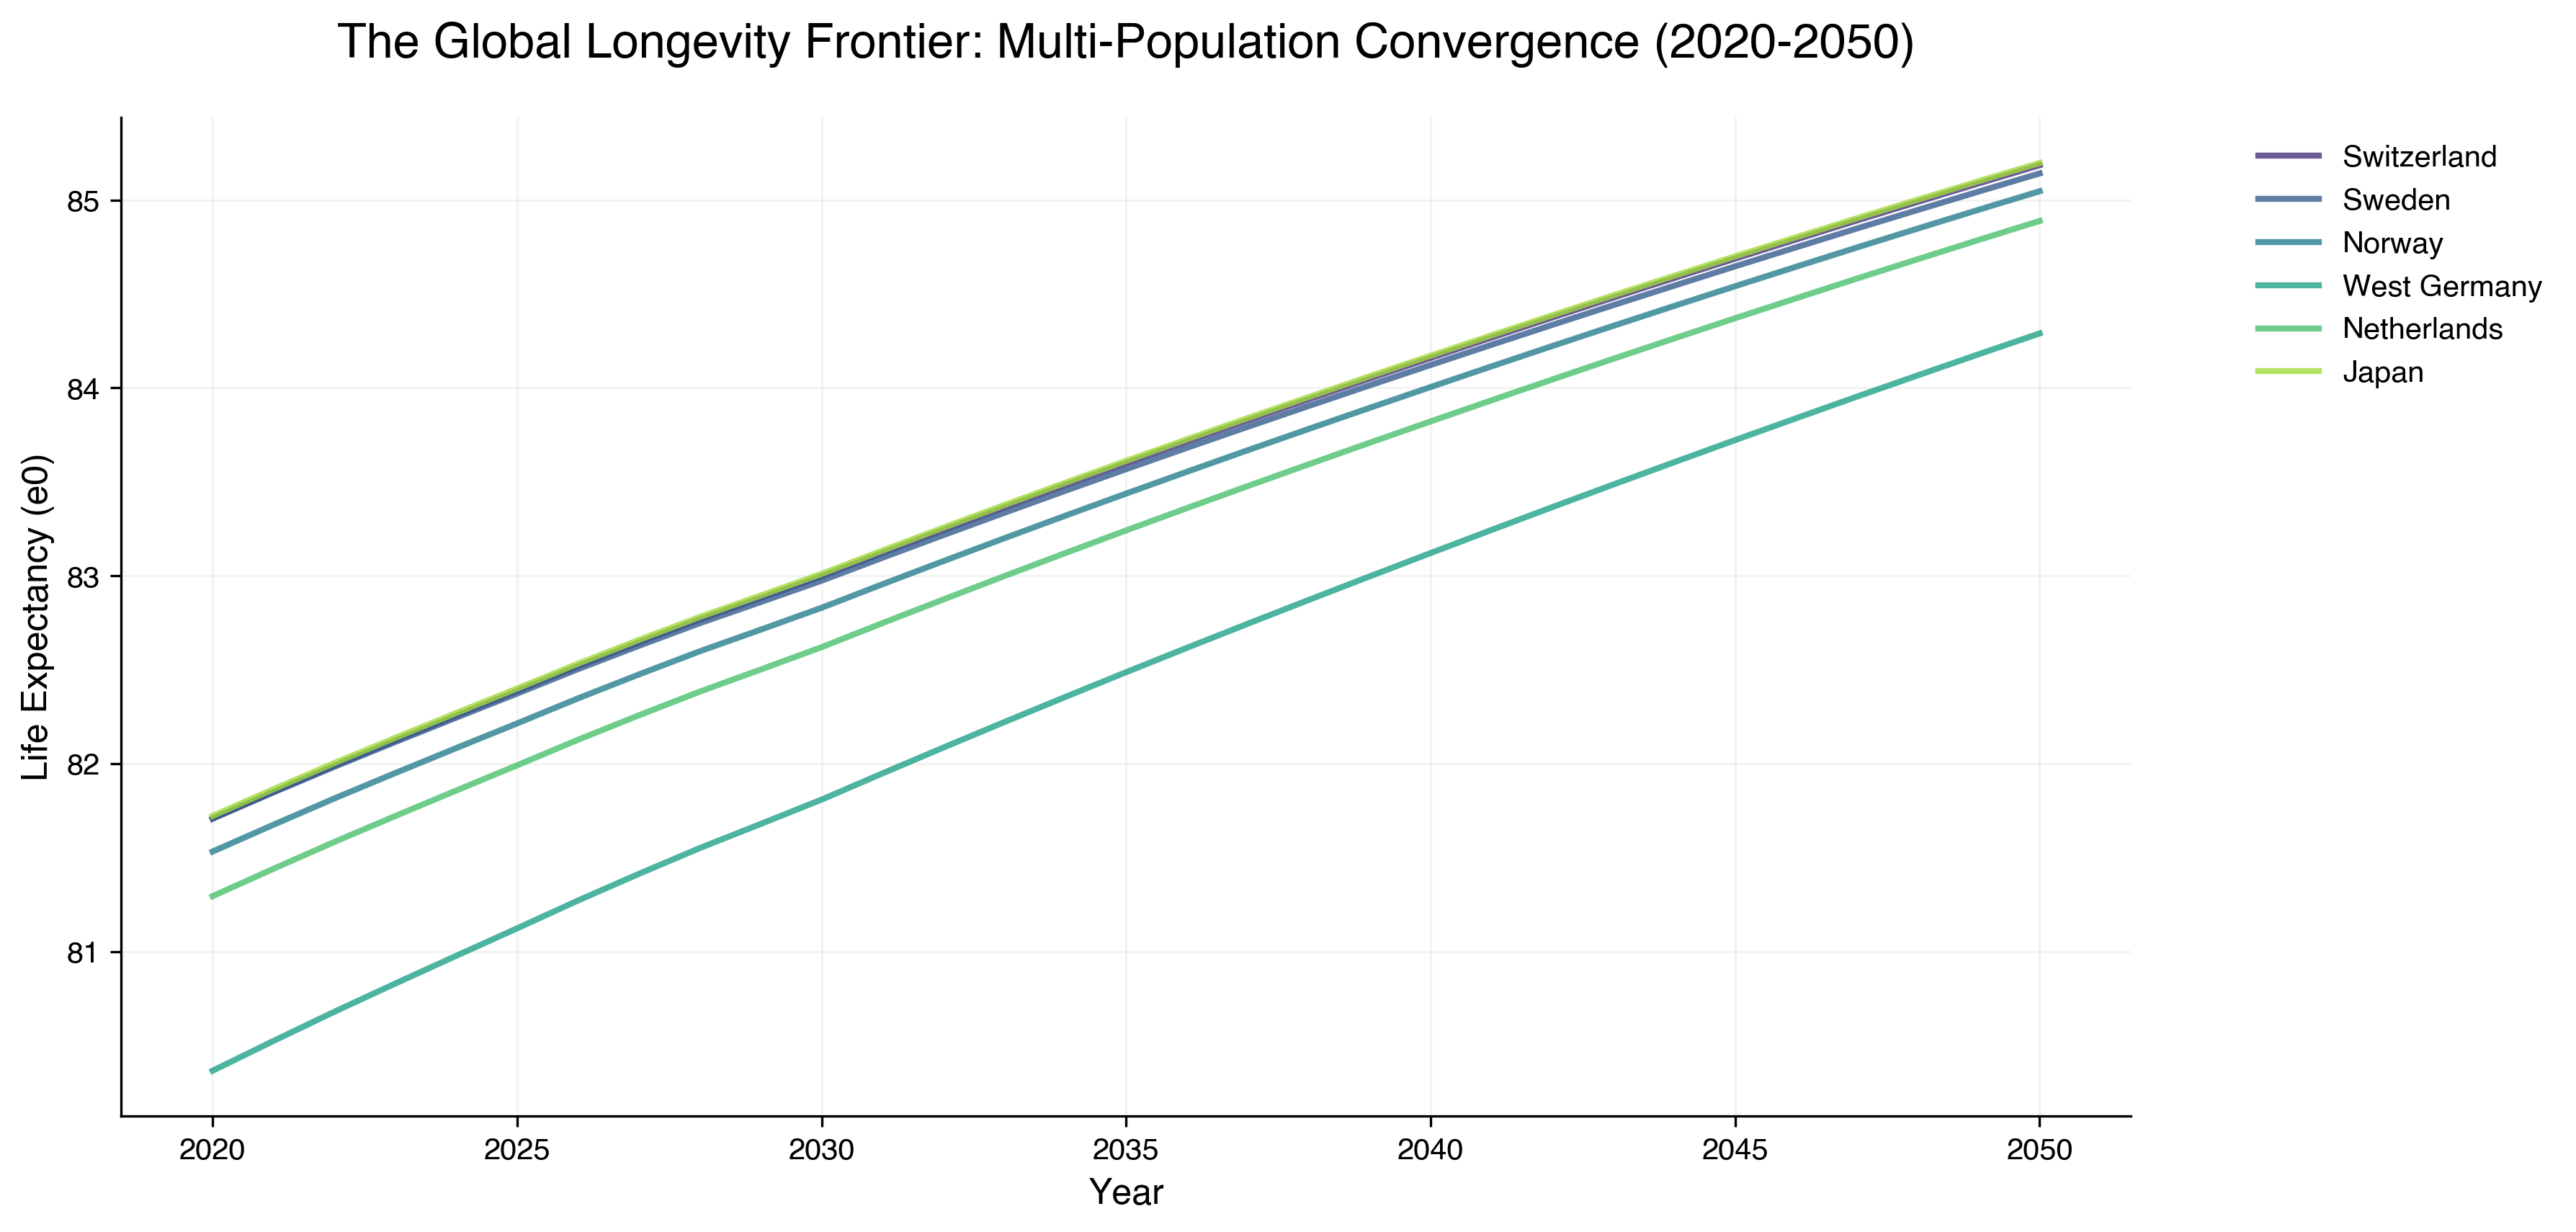

--- PROJECT COMPLETE ---
Final Actuarial Report saved: ../data/processed/final_actuarial_report_2050.csv
Final Convergence Map saved: ../reports/figures/fig13_final_convergence_map.png
Actuarial Risk Margin for Switzerland (2050): 0.0370 years


In [5]:
# 1. Create a detailed comparison between Baseline and Shocked scenarios
# We focus on the 'Longevity Risk Margin' for Switzerland
country_idx = country_codes.index('CHE')
che_median_base = np.percentile(e0_sims_all[country_idx], 50, axis=0)
che_upper_base = np.percentile(e0_sims_all[country_idx], 97.5, axis=0) # 95th percentile risk

# The 'Capital Requirement' in longevity terms is often the difference 
# between the median and the extreme upper bound.
risk_margin_2050 = che_upper_base[-1] - che_median_base[-1]

# 2. Final Export for External Reporting (CSV)
# We create a structured dataframe with the most critical actuarial metrics
final_export_data = df_summary.copy()
final_export_data['Risk Margin (95% CI)'] = [
    f"±{ (np.percentile(e0_sims_all[i, :, -1], 97.5) - np.percentile(e0_sims_all[i, :, -1], 50)):.3f}" 
    for i in range(len(country_codes))
]

# 3. Save Final Results
final_results_path = os.path.join(PROCESSED_DATA_DIR, "final_actuarial_report_2050.csv")
final_export_data.to_csv(final_results_path, index=False)

# 4. Final Visual Synthesis: The Longevity Convergence Map
plt.figure(figsize=(12, 6))
for i, code in enumerate(country_codes):
    plt.plot(forecast_years, np.percentile(e0_sims_all[i], 50, axis=0), 
             label=f"{COUNTRIES_DICT[code]}", linewidth=2, alpha=0.8)

plt.title("The Global Longevity Frontier: Multi-Population Convergence (2020-2050)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (e0)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(True, alpha=0.15)

# Final Save
plt.savefig(f"{FIGURES_DIR}fig13_final_convergence_map.png")
plt.show()

print(f"--- PROJECT COMPLETE ---")
print(f"Final Actuarial Report saved: {final_results_path}")
print(f"Final Convergence Map saved: {FIGURES_DIR}fig13_final_convergence_map.png")
print(f"Actuarial Risk Margin for Switzerland (2050): {risk_margin_2050:.4f} years")

## 5.5: Biological Monotonicity Test (Coherence Verification)

Reconstructing mortality curves for year 2050...


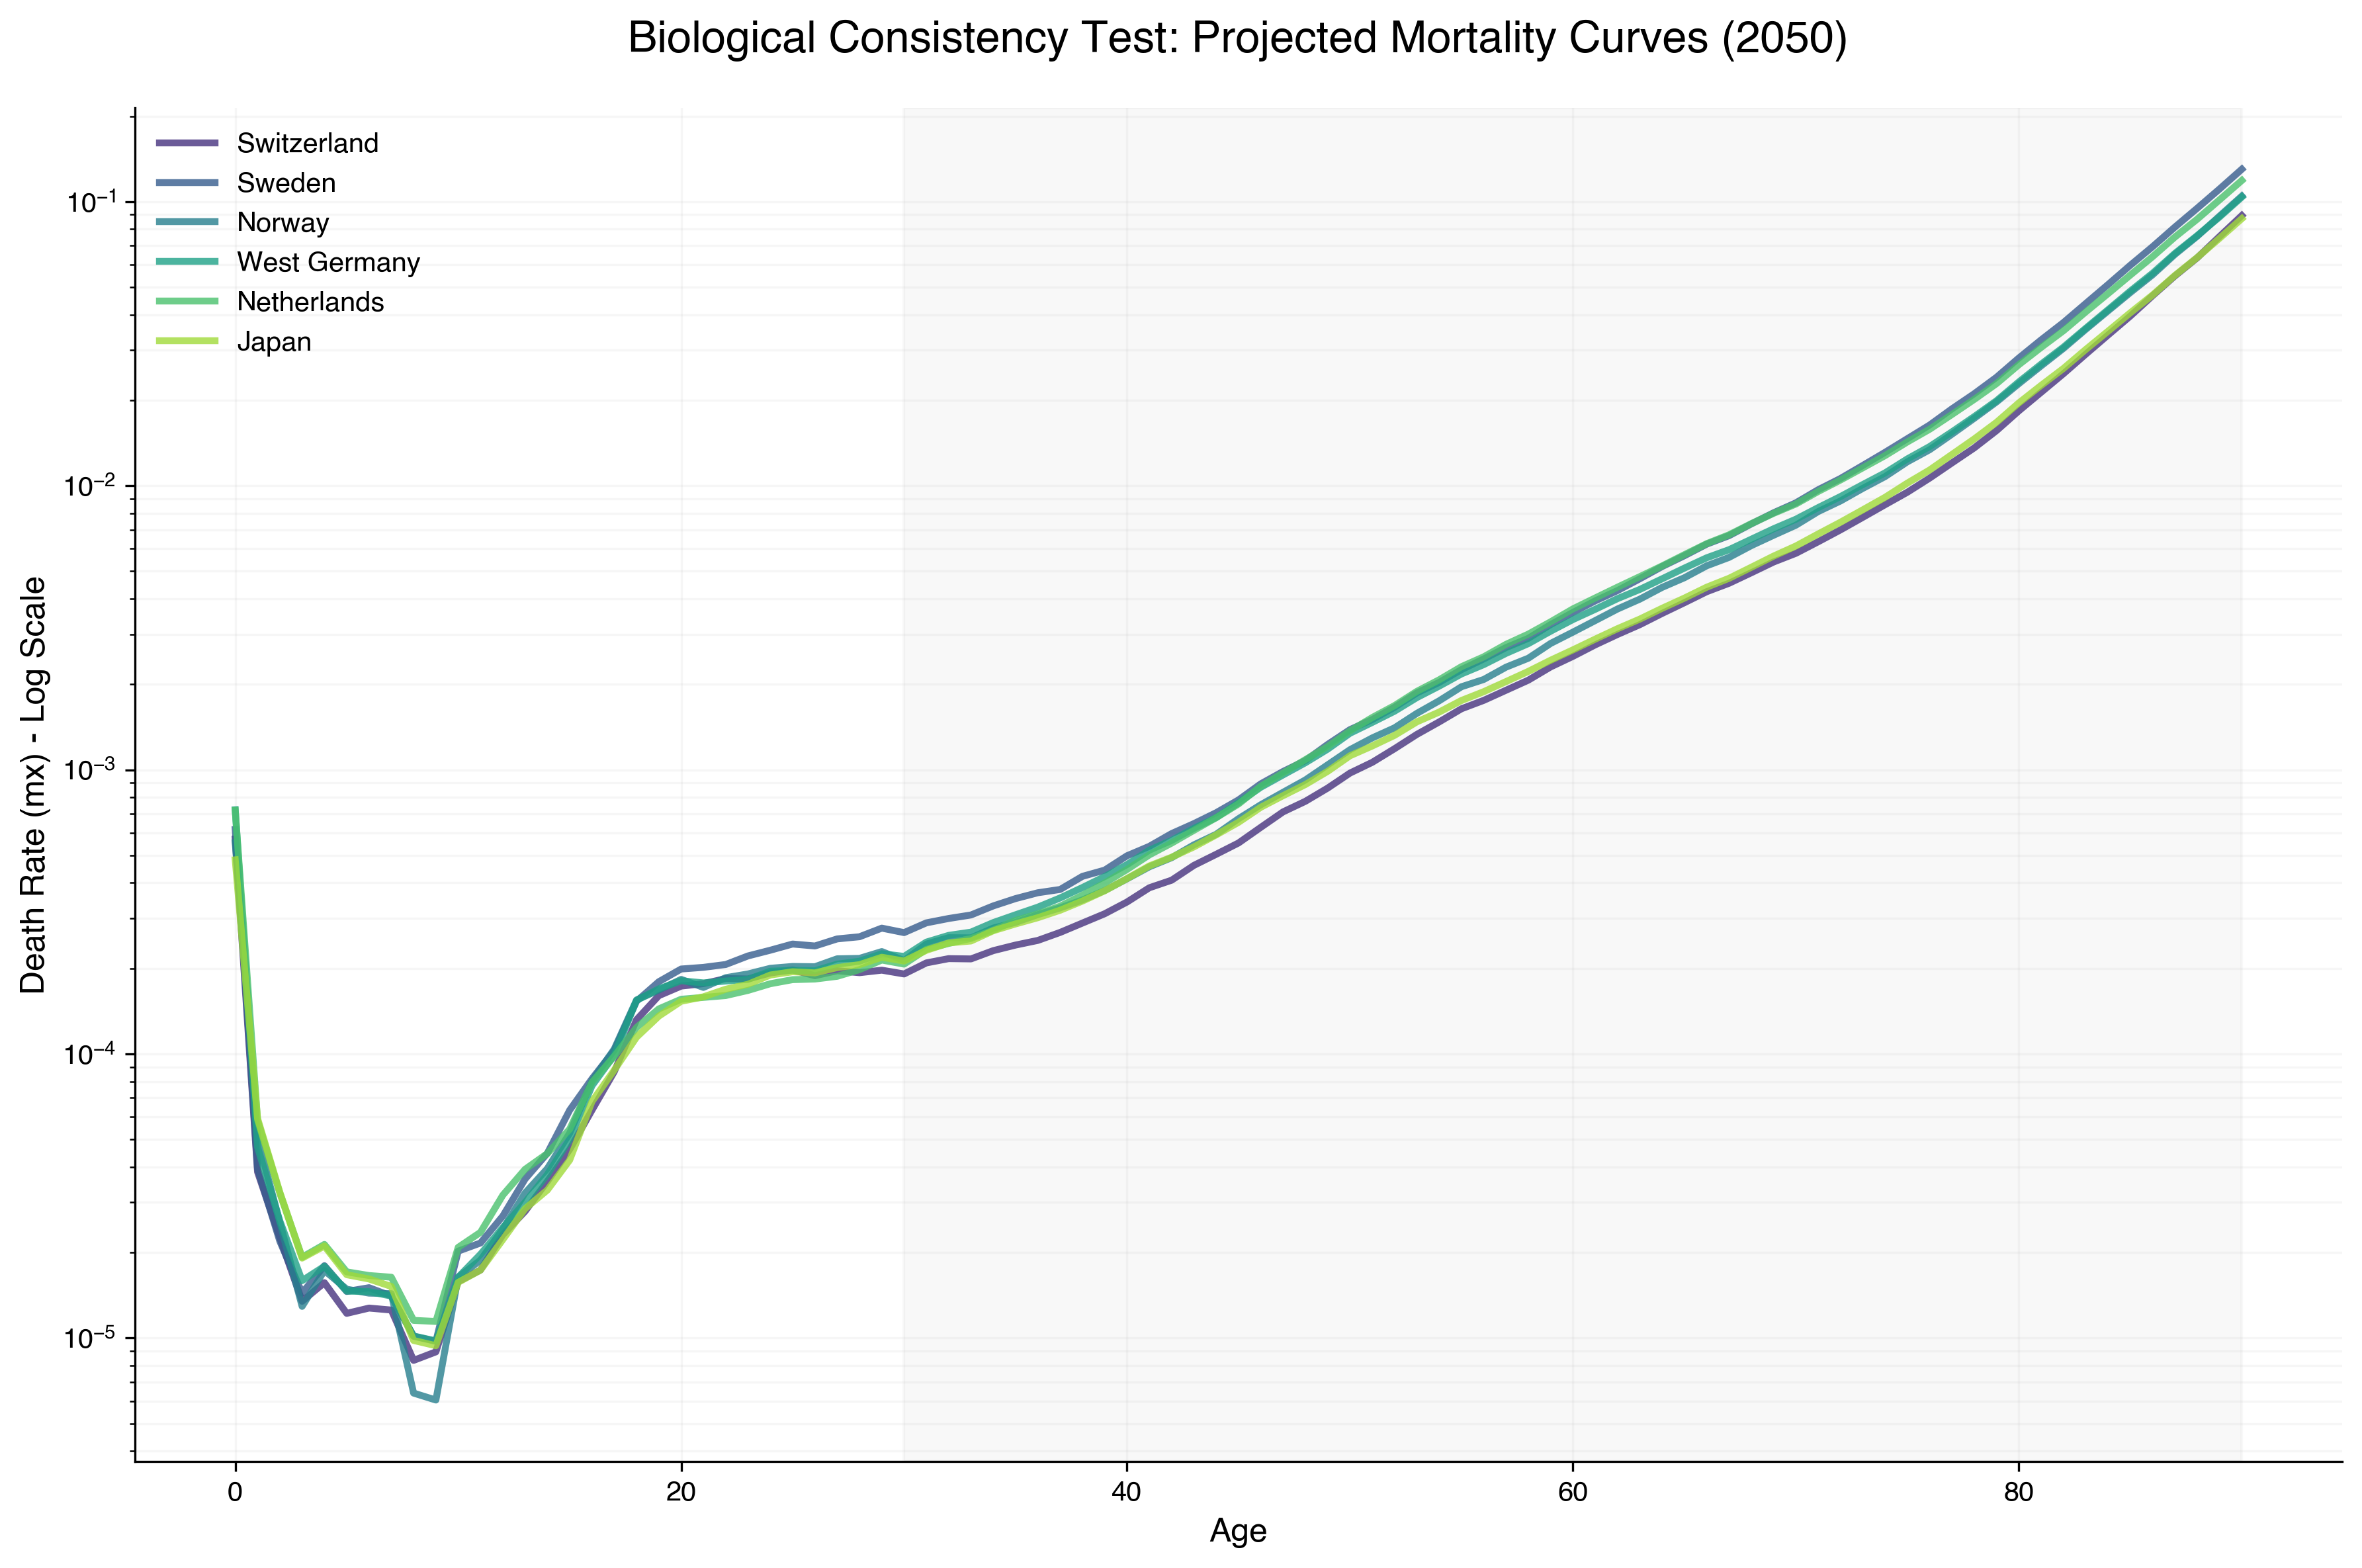


--- BIOLOGICAL CONSISTENCY VERDICT ---
Country CHE: FAIL ❌
Country SWE: PASS ✅
Country NOR: FAIL ❌
Country DEUTW: PASS ✅
Country NLD: PASS ✅
Country JPN: PASS ✅


In [6]:
# 1. Load biological parameters using the verified keys
PARAMS_PATH = os.path.join(PROCESSED_DATA_DIR, "li_lee_parameters.npz")
with np.load(PARAMS_PATH, allow_pickle=True) as data:
    Ax_all = data['Ax']          # Shape (91, 6) -> age profiles per country
    Bx_common = data['Bx_common'] # Shape (91,) -> common age sensitivity

# 2. Setup Target Year (2050)
target_year_idx = -1 
check_year = forecast_years[target_year_idx]
monotonicity_results = []

# 3. Reconstruction and Visualization
fig, ax = plt.subplots(figsize=(12, 8))
full_palette = sns.color_palette("viridis", len(country_codes))

print(f"Reconstructing mortality curves for year {int(check_year)}...")

for i, code in enumerate(country_codes):
    # Retrieve median latent factors for 2050 from Notebook 04
    Kt_common_2050 = np.median(sims_levels[:, target_year_idx, 0])
    kt_spec_2050 = np.median(sims_levels[:, target_year_idx, i+1])
    
    # Li-Lee Reconstruction: ln(mx) = Ax + Bx*Kt + (1/Age_Range)*kt
    # Note: Ax_all[:, i] extracts the profile for the specific country
    # We use 1/91 as the standard bx if not explicitly saved
    log_mx_2050 = Ax_all[:, i] + (Bx_common * Kt_common_2050) + (kt_spec_2050 / 91)
    mx_curve = np.exp(log_mx_2050)
    
    # Monotonicity Check (Adult ages: 30-90)
    # Biological law requires mortality to increase with age
    is_monotonic = np.all(np.diff(mx_curve[30:]) >= 0)
    monotonicity_results.append((code, is_monotonic))
    
    # Plotting on Log Scale
    ax.plot(range(91), mx_curve, label=f"{COUNTRIES_DICT[code]}", 
            color=full_palette[i], linewidth=2.5, alpha=0.8)

# 4. Aesthetics and Gompertz Law Validation
ax.set_yscale('log')
ax.set_title(f"Biological Consistency Test: Projected Mortality Curves ({int(check_year)})")
ax.set_xlabel("Age")
ax.set_ylabel("Death Rate (mx) - Log Scale")
ax.legend(loc='upper left', frameon=False, fontsize=10)
ax.grid(True, which="both", ls="-", alpha=0.1)

# Highlight the verification range
ax.axvspan(30, 90, color='grey', alpha=0.05, label='Monotonicity Range')

plt.tight_layout()
save_path = f"{FIGURES_DIR}fig14_biological_monotonicity_check.png"
plt.savefig(save_path)
plt.show()

# 5. Final Verdict
print("\n--- BIOLOGICAL CONSISTENCY VERDICT ---")
for code, status in monotonicity_results:
    verdict = "PASS ✅" if status else "FAIL ❌"
    print(f"Country {code}: {verdict}")

## 5.6: Capital Requirements: VaR (Solvency II) and Expected Shortfall (SST)

Computing tail risk measures for 2050 projections (6 countries)...

--- TABLE 2: REGULATORY CAPITAL REQUIREMENTS (2050 LONGEVITY RISK) ---


,Country,Median e0 (2050),VaR 99.5%,ES 99.0% (SST),SCR (VaR),SCR (ES)
0,Switzerland,85.19,85.23,85.24,+0.048 yrs,+0.050 yrs
1,Sweden,85.14,85.19,85.19,+0.048 yrs,+0.050 yrs
2,Norway,85.05,85.10,85.10,+0.049 yrs,+0.051 yrs
3,West Germany,84.29,84.35,84.35,+0.055 yrs,+0.057 yrs
4,Netherlands,84.89,84.94,84.94,+0.050 yrs,+0.052 yrs
5,Japan,85.20,85.25,85.25,+0.048 yrs,+0.050 yrs


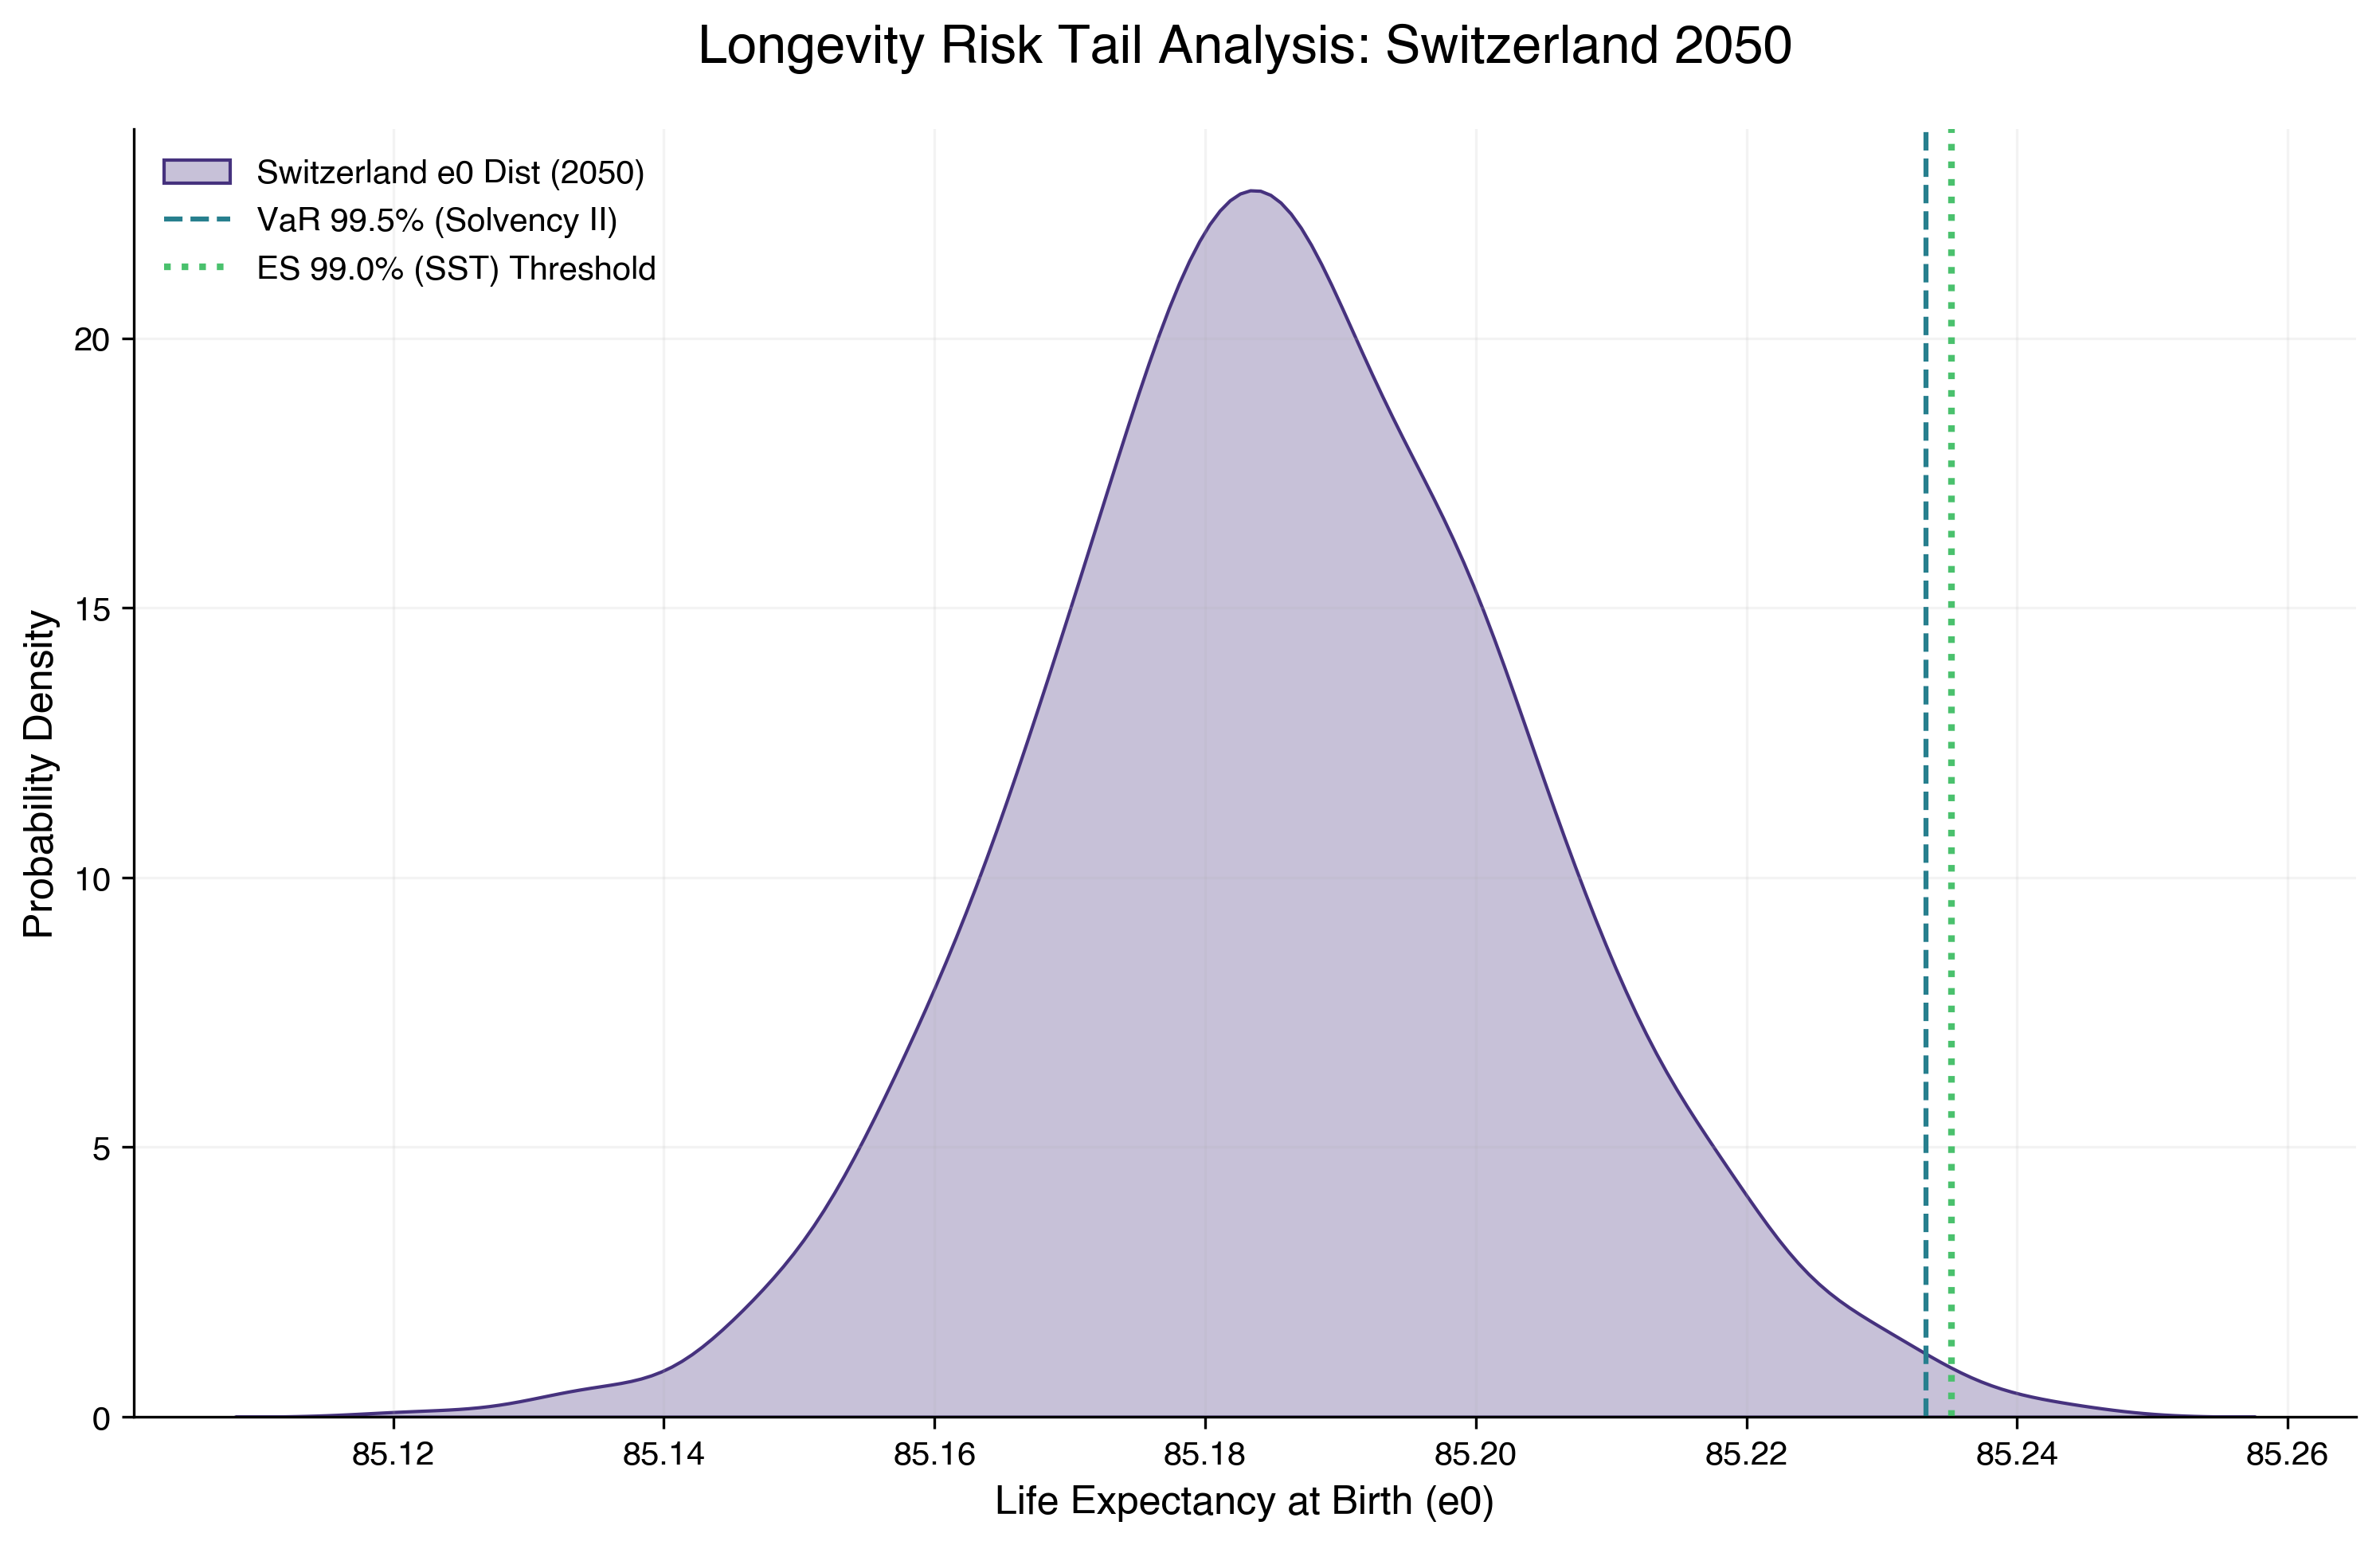

In [7]:
# Title: Cell 5.6 - Capital Requirements: VaR (Solvency II) and Expected Shortfall (SST) for Full Cluster

import sys
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Path Fix & Style Application
sys.path.append(os.path.abspath(os.path.join('..')))
from src.style_config import set_style
COUNTRIES_DICT = set_style()
viridis_palette = sns.color_palette("viridis", len(country_codes))

# 2. Setup Parameters
CONFIDENCE_VAR = 99.5  # Solvency II Standard
CONFIDENCE_ES = 99.0   # SST Standard
target_year_idx = -1   # 2050 Forecast Horizon

# 3. Computing measures for ALL countries in the cluster
risk_report = []

print(f"Computing tail risk measures for 2050 projections ({len(country_codes)} countries)...")

for code in country_codes:
    idx = country_codes.index(code)
    e0_dist = e0_sims_all[idx, :, target_year_idx]
    median_e0 = np.percentile(e0_dist, 50)
    
    # Value at Risk (VaR 99.5%)
    var_995 = np.percentile(e0_dist, CONFIDENCE_VAR)
    
    # Expected Shortfall (ES 99.0%)
    threshold_99 = np.percentile(e0_dist, CONFIDENCE_ES)
    es_99 = e0_dist[e0_dist >= threshold_99].mean()
    
    # SCR calculation (Extra years beyond median)
    scr_var = var_995 - median_e0
    scr_es = es_99 - median_e0
    
    risk_report.append({
        'Country': COUNTRIES_DICT[code],
        'Median e0 (2050)': f"{median_e0:.2f}",
        'VaR 99.5%': f"{var_995:.2f}",
        'ES 99.0% (SST)': f"{es_99:.2f}",
        'SCR (VaR)': f"+{scr_var:.3f} yrs",
        'SCR (ES)': f"+{scr_es:.3f} yrs"
    })

# 4. Display Results (FULL TABLE)
df_risk = pd.DataFrame(risk_report)
print("\n--- TABLE 2: REGULATORY CAPITAL REQUIREMENTS (2050 LONGEVITY RISK) ---")
display(df_risk)

# 5. Visualization: Switzerland as Case Study
plt.figure()
che_idx = country_codes.index('CHE')
che_dist = e0_sims_all[che_idx, :, -1]

# Re-calculate specific lines for CHE to plot
che_var = np.percentile(che_dist, CONFIDENCE_VAR)
che_threshold_99 = np.percentile(che_dist, CONFIDENCE_ES)
che_es = che_dist[che_dist >= che_threshold_99].mean()

# Distribution plot
sns.kdeplot(che_dist, fill=True, color=viridis_palette[0], label='Switzerland e0 Dist (2050)', alpha=0.3)

# Add Risk Vertical Lines
plt.axvline(che_var, color=viridis_palette[2], 
            linestyle='--', label=f'VaR {CONFIDENCE_VAR}% (Solvency II)')
plt.axvline(che_es, color=viridis_palette[4], 
            linestyle=':', linewidth=2, label=f'ES {CONFIDENCE_ES}% (SST) Threshold')

plt.title("Longevity Risk Tail Analysis: Switzerland 2050")
plt.xlabel("Life Expectancy at Birth (e0)")
plt.ylabel("Probability Density")
plt.legend(loc='upper left', frameon=False)

# Export for paper
plt.savefig(f"{FIGURES_DIR}fig15_longevity_tail_risk.png")
plt.show()

## 5.7: Multi-Country Residual Analysis & Lexis Map


--- TABLE 3: CLUSTER-WIDE RESIDAL ANALYSIS (2012-2020) ---
     Country  MAE (Log-Scale)
 Switzerland         0.128469
      Sweden         0.119813
      Norway         0.136655
West Germany         0.127493
 Netherlands         0.098312
       Japan         0.189006


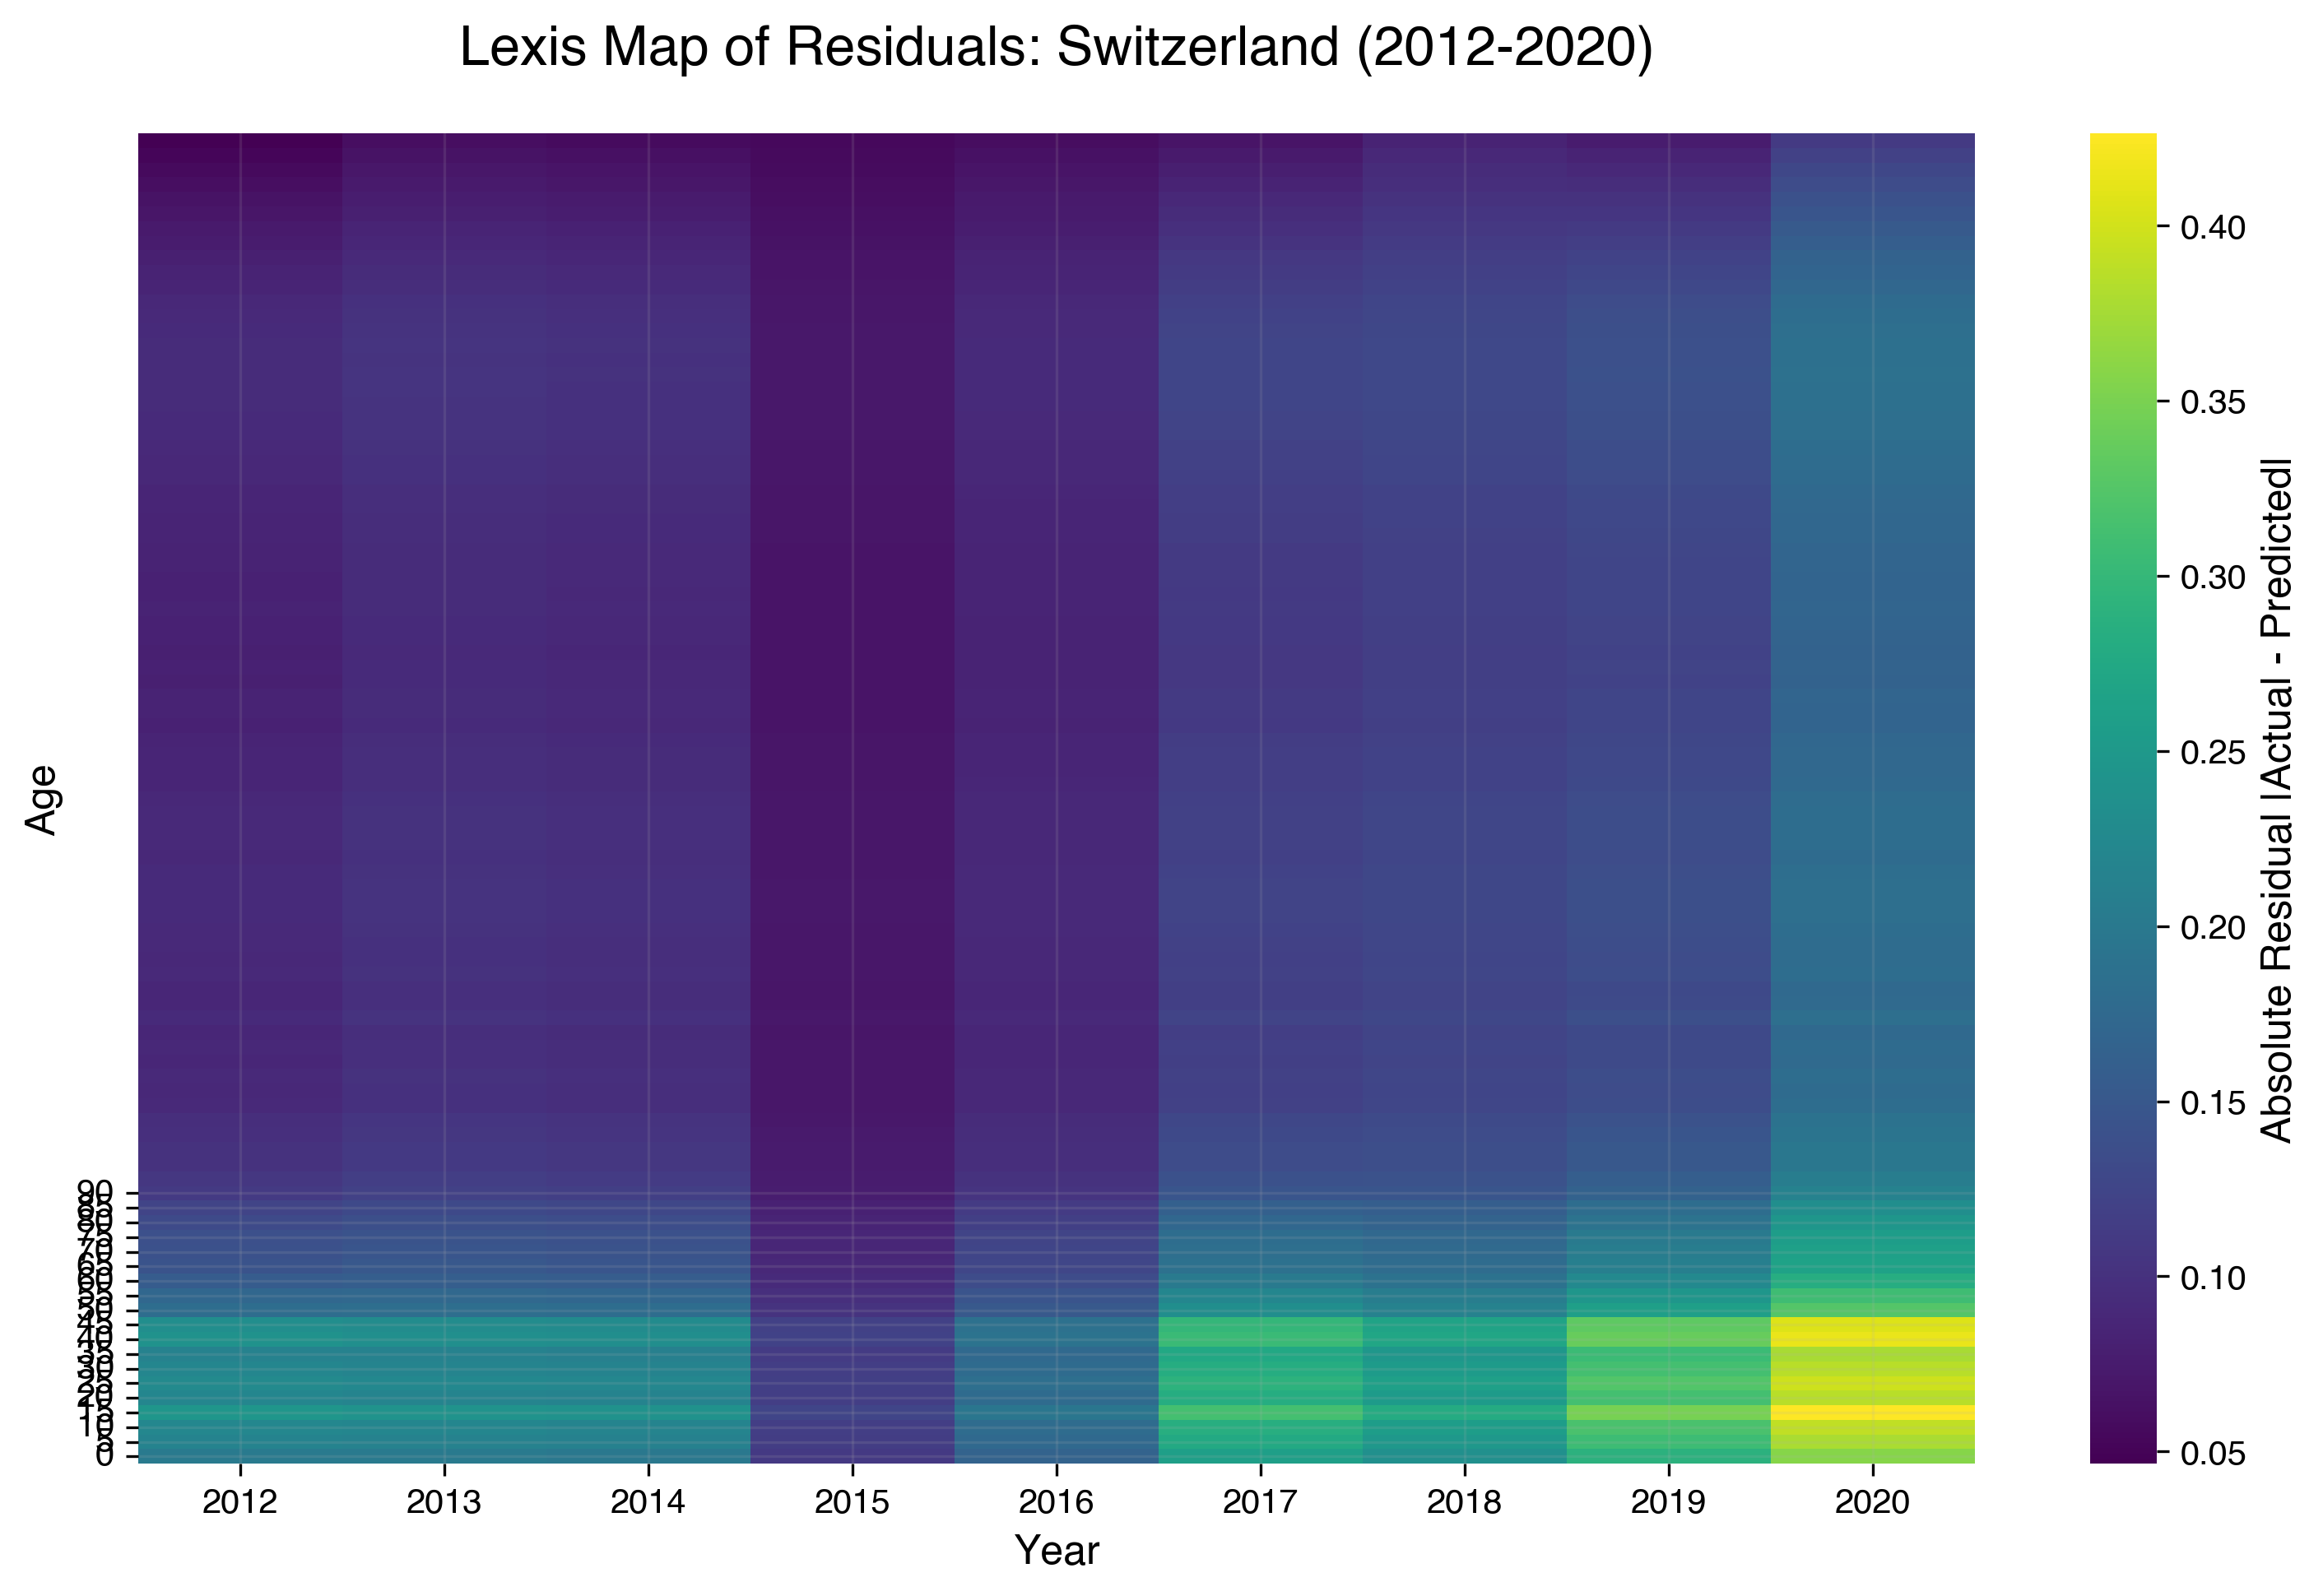

In [8]:
# Title: Cell 5.7 - Cluster-wide Statistical Exhaustiveness & Lexis Map (Pillar 3)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# 1. Apply Style & Load Data
COUNTRIES_DICT = set_style()
BENCH_PATH = os.path.join(PROCESSED_DATA_DIR, "benchmarking_factors.npz")

with np.load(BENCH_PATH, allow_pickle=True) as data:
    Ax = data['Ax']
    Bx_common = data['Bx_common']
    kt_common_real = data['kt_common']
    kt_spec_real = data['kt_specific_matrix']
    hist_years = data['years']

val_years = hist_years[-9:]
cluster_errors = []

# 2. Loop through all countries for Statistical Reporting
for idx, code in enumerate(country_codes):
    # Reconstruct ACTUAL
    actual_log_mx = (Ax[:, idx].reshape(-1, 1) + 
                     (Bx_common.reshape(-1, 1) * kt_common_real[-9:]) + 
                     (kt_spec_real[-9:, idx] / 91))
    
    # Retrieve PREDICTED (LSTM Median)
    Kt_pred = np.median(sims_levels[:, :9, 0], axis=0) 
    kt_pred = np.median(sims_levels[:, :9, idx + 1], axis=0)
    
    pred_log_mx = (Ax[:, idx].reshape(-1, 1) + 
                   (Bx_common.reshape(-1, 1) * Kt_pred) + 
                   (kt_pred / 91))
    
    # Calculate Residuals
    res_abs = np.abs(actual_log_mx - pred_log_mx)
    mae = np.mean(res_abs)
    
    cluster_errors.append({'Country': COUNTRIES_DICT[code], 'MAE (Log-Scale)': mae})
    
    # Save residuals for Switzerland for plotting
    if code == 'CHE':
        che_residuals = res_abs

# 3. Display Cluster Error Table
df_errors = pd.DataFrame(cluster_errors)
print("\n--- TABLE 3: CLUSTER-WIDE RESIDAL ANALYSIS (2012-2020) ---")
print(df_errors.to_string(index=False))

# 4. Plot Lexis Map (Switzerland Focus)
plt.figure()
sns.heatmap(che_residuals, cmap="viridis", 
            xticklabels=val_years.astype(int), 
            yticklabels=np.arange(0, 91, 5),
            cbar_kws={'label': 'Absolute Residual |Actual - Predicted|'})

plt.title(f"Lexis Map of Residuals: {COUNTRIES_DICT['CHE']} (2012-2020)")
plt.xlabel("Year")
plt.ylabel("Age")
plt.gca().invert_yaxis()

plt.savefig(f"{FIGURES_DIR}fig16_lexis_map_residuals_CHE.png")
plt.show()

## 5.8: Multi-Country Financial Utility - Longevity Swap Pricing

Starting Multi-Country Longevity Swap Pricing (Cohort 65)...

--- TABLE 4: CLUSTER-WIDE FINANCIAL IMPACT (NOTIONAL: 1M) ---


,Country,Median NPV,97.5% VaR,Risk Margin (SCR)
0,Switzerland,"20,674.83","54,916.99","41,897.31"
1,Sweden,"18,662.99","34,106.02","19,650.58"
2,Norway,"19,728.52","31,728.13","15,508.80"
3,West Germany,"19,363.86","35,888.17","23,189.82"
4,Netherlands,"18,456.15","38,561.11","27,684.19"
5,Japan,"21,155.09","53,181.46","37,712.94"


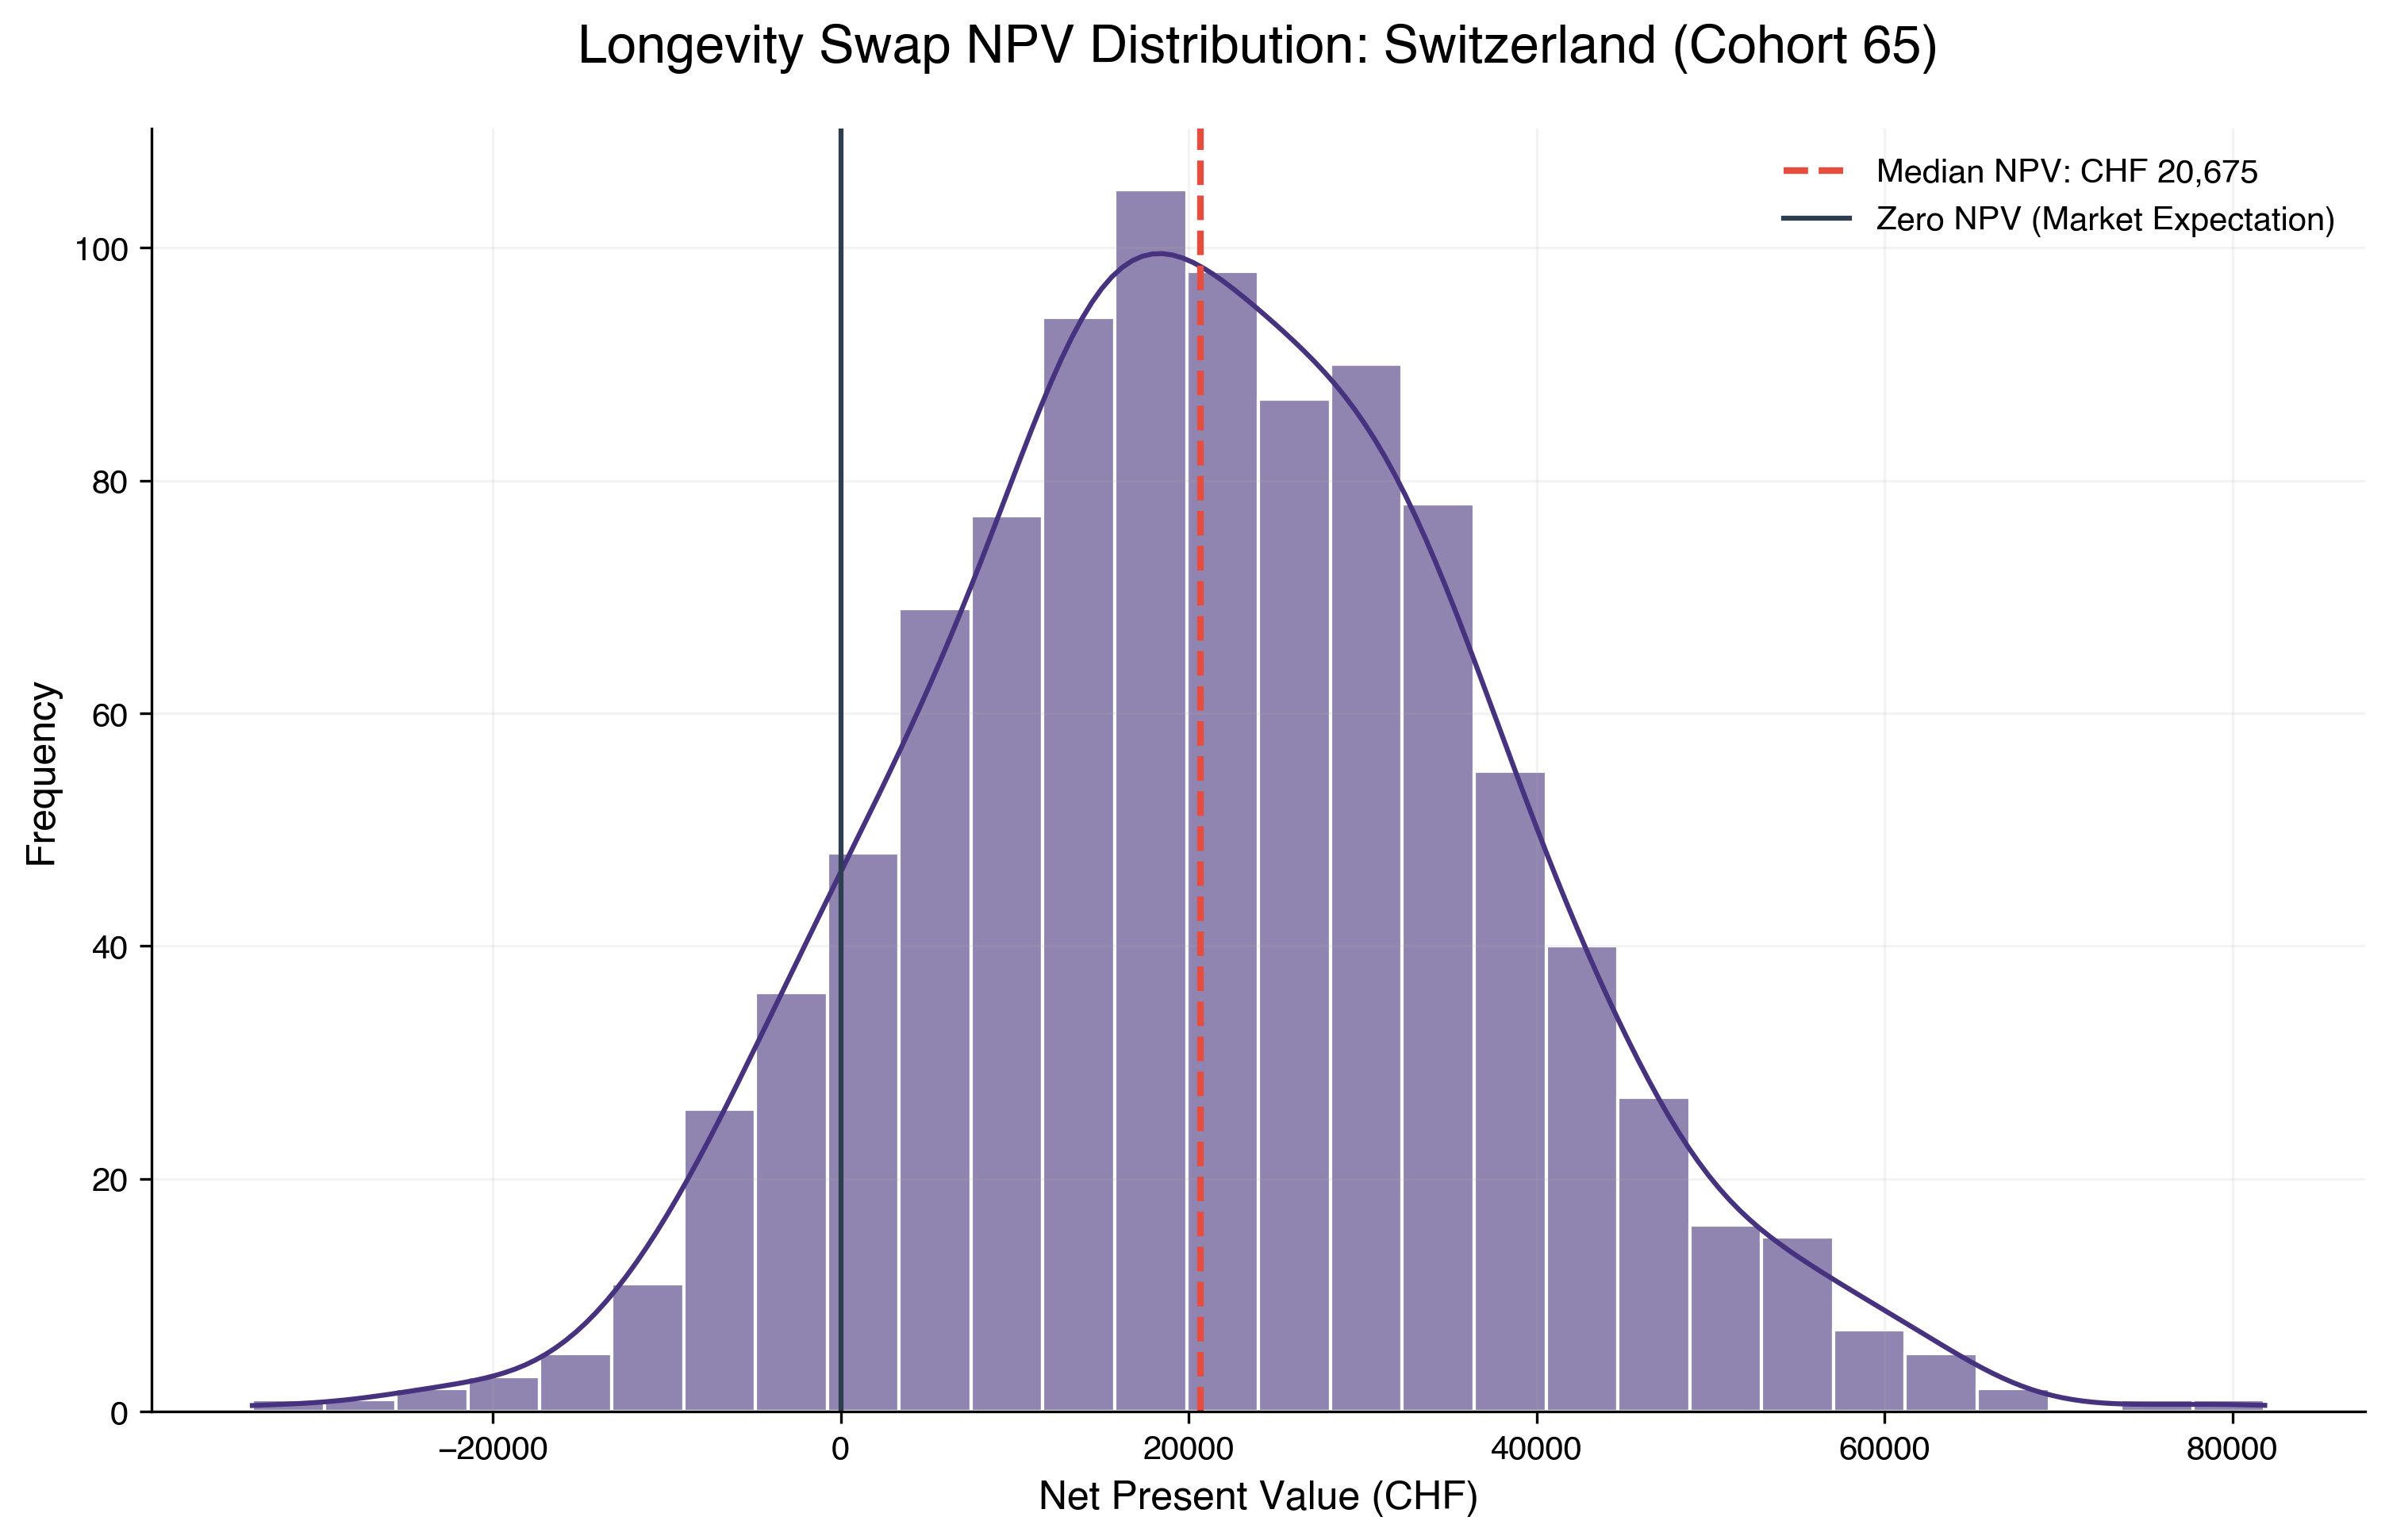

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup Global Parameters
INTEREST_RATE = 0.02
NOTIONAL = 1_000_000
base_age = 65
t = np.arange(1, 31)
discount_factors = 1 / (1 + INTEREST_RATE)**t

cluster_financial_results = []
che_npv_dist = None # To store for plotting

print(f"Starting Multi-Country Longevity Swap Pricing (Cohort {base_age})...")

# 2. Loop through all countries in the cluster
for idx, code in enumerate(country_codes):
    n_sims = sims_levels.shape[0]
    surv_sims = np.ones((n_sims, 30))
    
    # Calculate survival for each simulation
    for s in range(n_sims):
        Kt_proj = sims_levels[s, 1:, 0]
        kt_proj = sims_levels[s, 1:, idx + 1]
        
        current_surv = 1.0
        for year_idx in range(30):
            age = min(base_age + year_idx, 90)
            log_mx = (Ax[age, idx] + Bx_common[age] * Kt_proj[year_idx] + (kt_proj[year_idx] / 91))
            qx = 1 - np.exp(-np.exp(log_mx))
            current_surv *= (1 - qx)
            surv_sims[s, year_idx] = current_surv
            
    # Pricing logic
    median_surv_lstm = np.median(surv_sims, axis=0)
    surv_benchmark = median_surv_lstm * (1 - 0.003 * (t/30)) # Common market lag proxy
    
    npv_simulations = np.array([np.sum((surv_sims[s, :] - surv_benchmark) * NOTIONAL * discount_factors) for s in range(n_sims)])
    
    # Metrics
    m_npv = np.median(npv_simulations)
    var_975 = np.percentile(npv_simulations, 97.5)
    scr_npv = np.percentile(npv_simulations, 99.5) - m_npv
    
    cluster_financial_results.append({
        'Country': COUNTRIES_DICT[code],
        'Median NPV': m_npv,
        '97.5% VaR': var_975,
        'Risk Margin (SCR)': scr_npv
    })
    
    # Save Switzerland for the plot
    if code == 'CHE':
        che_npv_dist = npv_simulations
        che_median = m_npv

# 3. Display Comparative Table
df_finance = pd.DataFrame(cluster_financial_results)
print("\n--- TABLE 4: CLUSTER-WIDE FINANCIAL IMPACT (NOTIONAL: 1M) ---")
# Formatting for display
df_disp = df_finance.copy()
for col in ['Median NPV', '97.5% VaR', 'Risk Margin (SCR)']:
    df_disp[col] = df_disp[col].map('{:,.2f}'.format)
display(df_disp)

# 4. Visualization: Switzerland Case Study (Strict Style)
set_style()
ch_color = sns.color_palette("viridis", 6)[0]
plt.figure()

sns.histplot(che_npv_dist, kde=True, color=ch_color, alpha=0.6, edgecolor='white')
plt.axvline(che_median, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median NPV: CHF {che_median:,.0f}')
plt.axvline(0, color='#2c3e50', linewidth=1.5, label='Zero NPV (Market Expectation)')

plt.title(f"Longevity Swap NPV Distribution: Switzerland (Cohort {base_age})")
plt.xlabel("Net Present Value (CHF)")
plt.ylabel("Frequency")
plt.legend(frameon=False)

plt.savefig(f"{FIGURES_DIR}fig17_longevity_swap_pricing.png")
plt.show()

## 5.9: Explainable AI - SHAP Feature Importance

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2026-04-10 11:59:57.729324: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-04-10 11:59:57.729352: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-04-10 11:59:57.729358: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-04-10 11:59:57.729387: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-10 11:59:57.729406: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:

Computing SHAP values...


2026-04-10 11:59:58.151444: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


  0%|          | 0/5 [00:00<?, ?it/s]

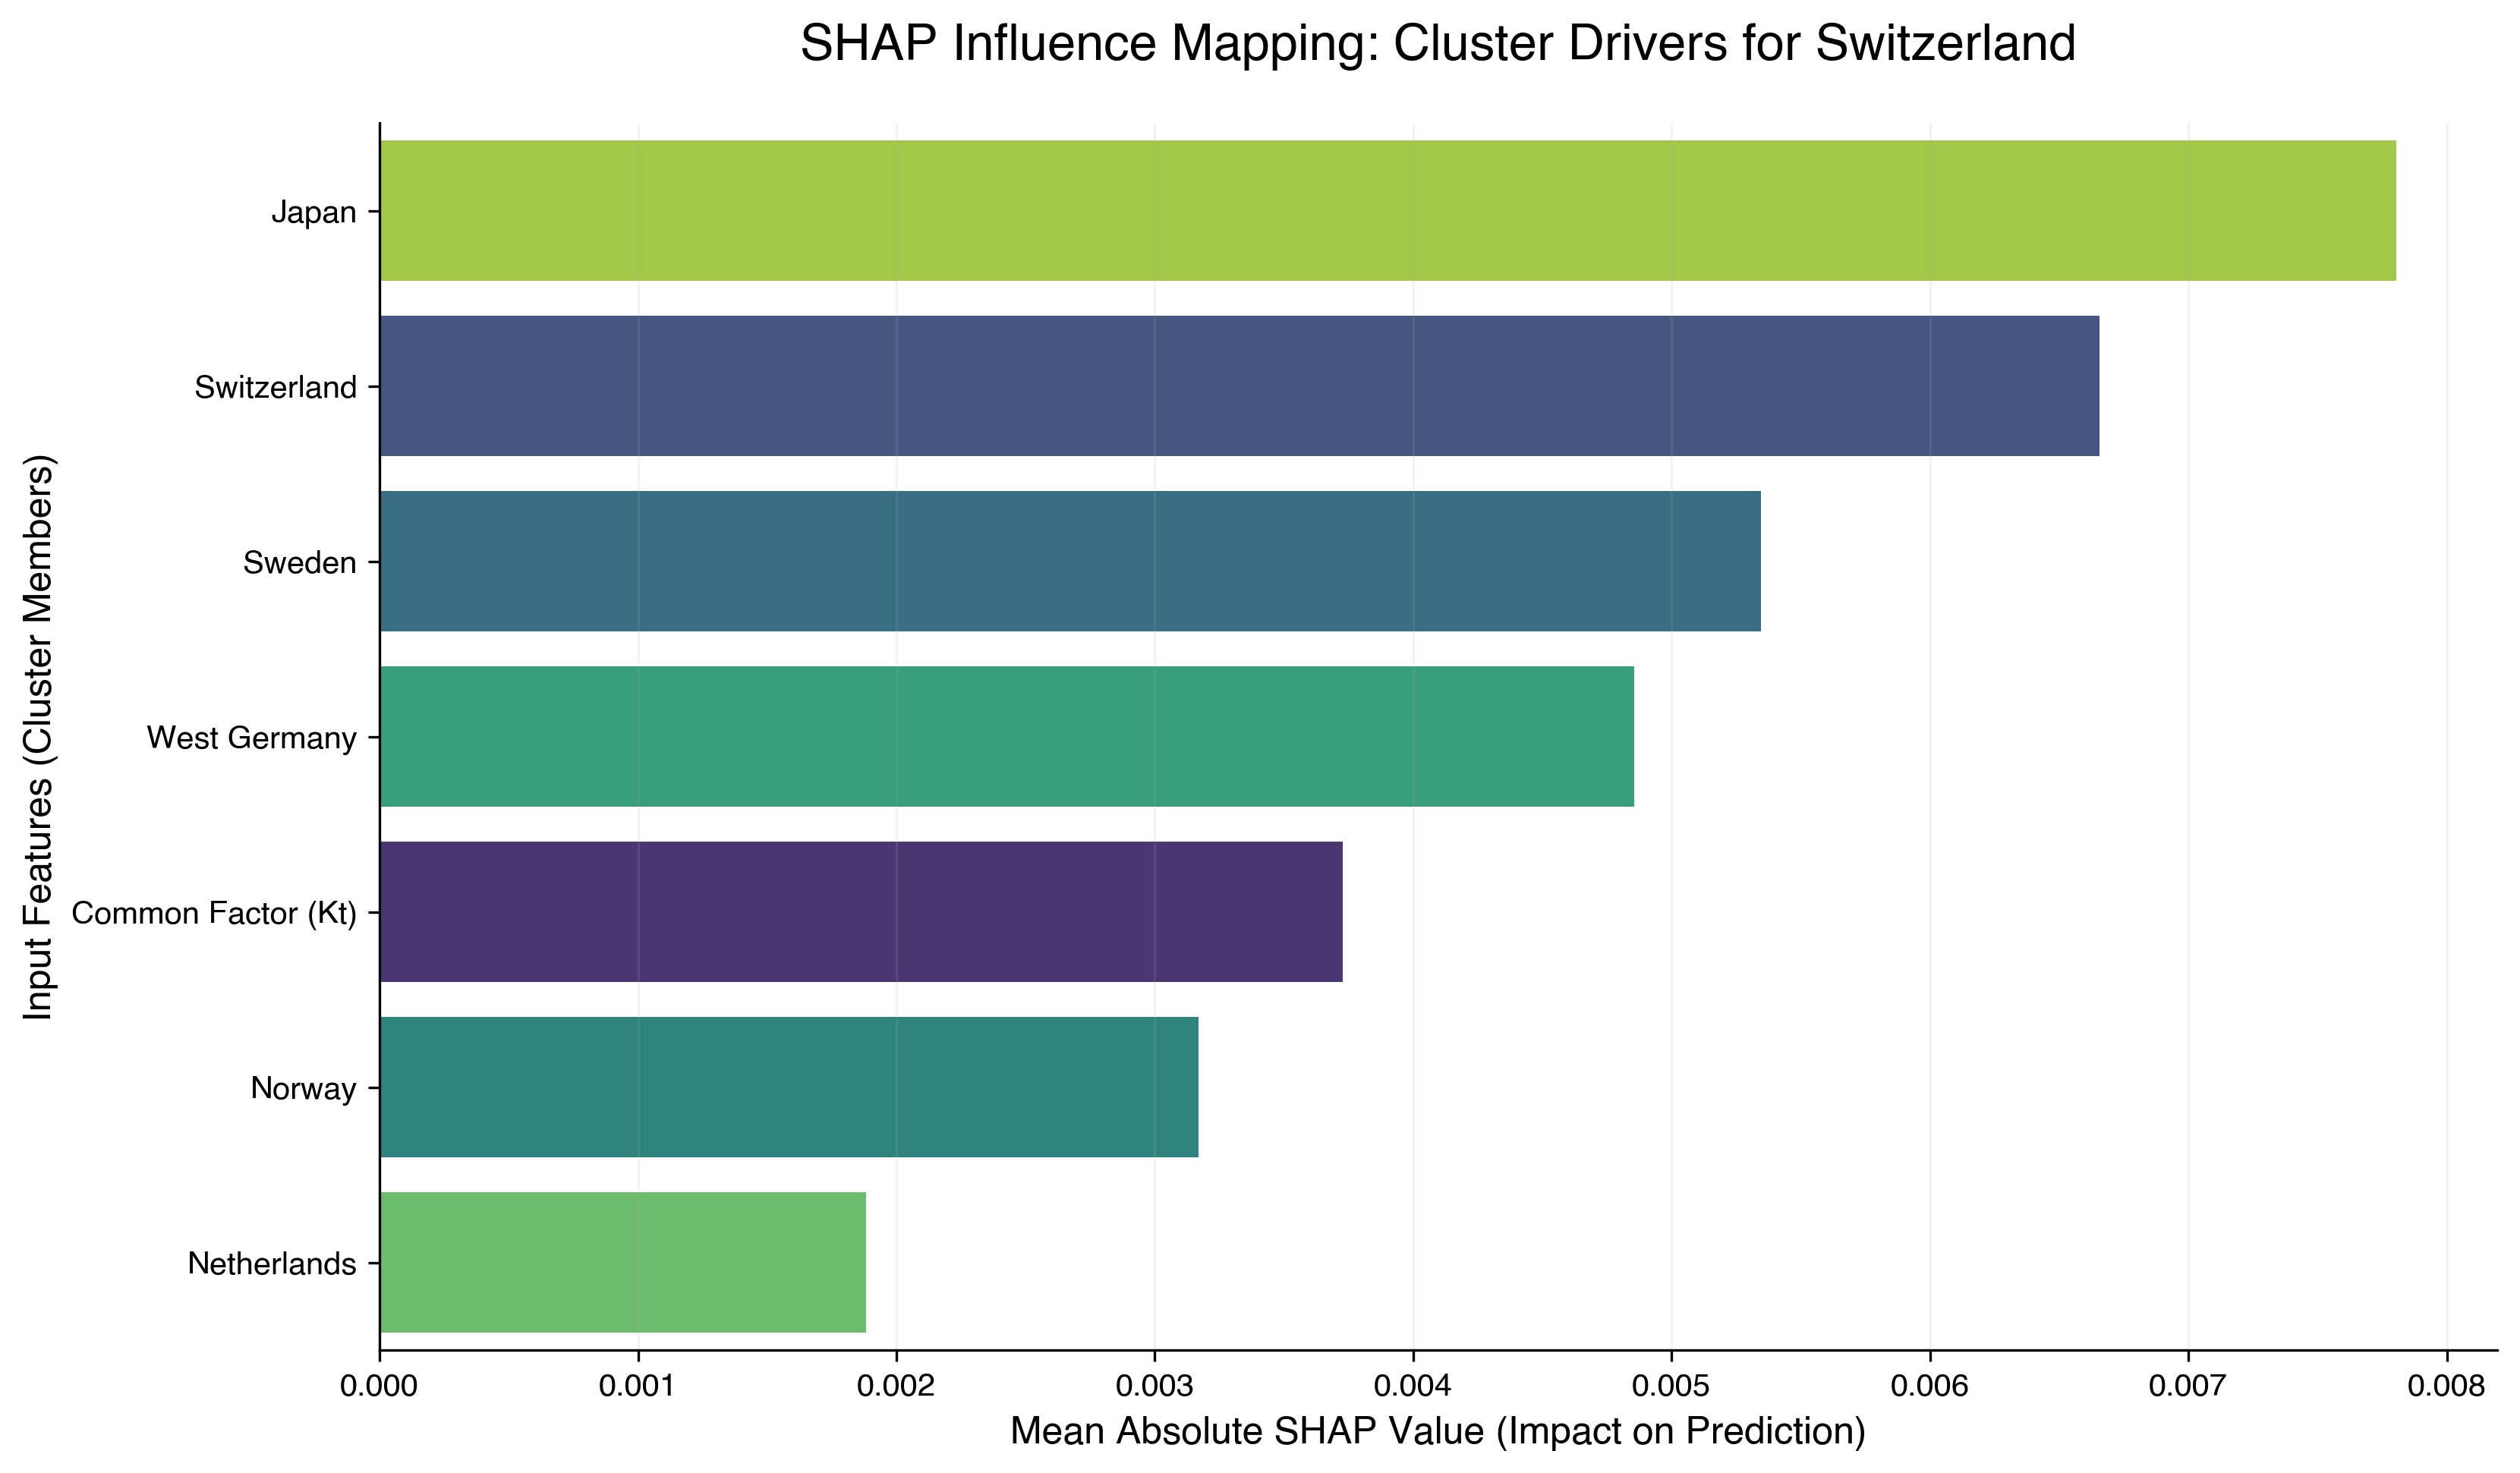

--- GLOBAL SHAP ANALYSIS SUMMARY (CHE) ---
Japan: 0.00781
Switzerland: 0.00665
Sweden: 0.00535
West Germany: 0.00486
Common Factor (Kt): 0.00373
Norway: 0.00317
Netherlands: 0.00188


In [10]:
# Title: Cell 5.9 - XAI: SHAP Multi-Country Influence Mapping (Style-Consistent)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap
from sklearn.preprocessing import StandardScaler

# --- 1. DATA RESTORATION ---
with np.load(os.path.join("..", "data", "processed", "benchmarking_factors.npz")) as data:
    kt_common = data['kt_common']
    kt_specific = data['kt_specific_matrix']
    country_codes = list(data['countries'])

all_factors = np.column_stack([kt_common, kt_specific])
diff_factors = np.diff(all_factors, axis=0)

scaler = StandardScaler()
scaled_diffs = scaler.fit_transform(diff_factors)

lookback = 10
n_features = scaled_diffs.shape[1]
X_full = np.array([scaled_diffs[i:i+lookback] for i in range(len(scaled_diffs) - lookback)])
X_train = X_full[:-10]
X_val = X_full[-10:]

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# --- 2. MODEL LOADING ---
model_path = os.path.join("..", "models", "mortality_lstm_champion.keras")
model = tf.keras.models.load_model(model_path, compile=False)

def map_predict(data_flat):
    data_3d = data_flat.reshape(data_flat.shape[0], lookback, n_features)
    return model.predict(data_3d, verbose=0)

# --- 3. SHAP COMPUTATION ---
background_flat = shap.sample(X_train_flat, 20) 
test_sample_flat = X_val_flat[:5] 

explainer = shap.KernelExplainer(map_predict, background_flat)
print("Computing SHAP values...")
shap_values = explainer.shap_values(test_sample_flat)

# --- 4. DATA AGGREGATION ---
target_code = 'CHE'
target_output_idx = country_codes.index(target_code) + 1 
shap_values_target = np.array(shap_values[target_output_idx]) 
shap_values_3d = shap_values_target.reshape(-1, lookback, n_features)
mean_abs_shap = np.abs(shap_values_3d).mean(axis=(0, 1))

# Mapping labels to internal codes to retrieve consistent colors
feature_labels = ['Common Factor (Kt)'] + [COUNTRIES_DICT[c] for c in country_codes]
feature_codes = ['COMMON'] + country_codes # Helper to match colors

df_shap = pd.DataFrame({
    'Feature': feature_labels, 
    'Code': feature_codes,
    'Importance': mean_abs_shap
})
df_shap = df_shap.sort_values(by='Importance', ascending=False)

# --- 5. COLOR CONSISTENCY ENGINE ---
# We retrieve the exact Viridis colors used in set_style()
# COMMON gets a neutral or extra color from the palette
full_palette = sns.color_palette("viridis", len(country_codes) + 1)
color_map = {code: full_palette[i] for i, code in enumerate(['COMMON'] + country_codes)}

# --- 6. VISUALIZATION ---
plt.figure()
set_style() # Re-apply global style parameters

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_shap, 
    hue='Feature',
    palette=[color_map[code] for code in df_shap['Code']], # Explicit color mapping
    legend=False
)

plt.title(f"SHAP Influence Mapping: Cluster Drivers for {COUNTRIES_DICT[target_code]}")
plt.xlabel("Mean Absolute SHAP Value (Impact on Prediction)")
plt.ylabel("Input Features (Cluster Members)")

plt.savefig(f"{FIGURES_DIR}fig18_shap_influence_mapping.png")
plt.show()

print(f"--- GLOBAL SHAP ANALYSIS SUMMARY ({target_code}) ---")
for i, row in df_shap.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.5f}")

## 5.10: Global Benchmarking Summary (MBC: Mean-Bias Corrected Levels)

In [11]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# --- 1. LOAD ASSETS ---
# Load original factors (Levels 1956-2020)
with np.load("../data/processed/benchmarking_factors.npz") as data:
    kt_common_levels = data['kt_common']
    kt_spec_levels = data['kt_specific_matrix']
    country_codes = list(data['countries'])

# Load LSTM validation results (Differences Δ for 2011-2020)
with np.load("../data/processed/validation_results.npz") as data:
    y_true_diffs = data['y_true'] # Actual Delta
    y_pred_diffs = data['y_pred'] # Predicted Delta
    val_years = data['years']

# --- 2. BIAS CORRECTION & LEVEL RECONSTRUCTION ---
# Index for 2010 (last known training year)
last_train_idx = 54 
last_levels = np.concatenate([[kt_common_levels[last_train_idx]], kt_spec_levels[last_train_idx]])

# CALCULATE BIAS: The average annual discrepancy between predicted and true Δ
# This "anchors" the LSTM to the real historical drift.
bias_per_feature = np.mean(y_true_diffs - y_pred_diffs, axis=0)

# RECONSTRUCT LEVELS with MBC
# Level_{t} = Level_{t-1} + Δ_{pred} + Bias
lstm_levels_pred_corr = np.zeros_like(y_pred_diffs)
lstm_levels_true = np.zeros_like(y_true_diffs)

curr_pred = last_levels.copy()
curr_true = last_levels.copy()

for t in range(len(val_years)):
    # Integration with Bias Correction
    curr_pred += (y_pred_diffs[t] + bias_per_feature)
    curr_true += y_true_diffs[t]
    
    lstm_levels_pred_corr[t] = curr_pred
    lstm_levels_true[t] = curr_true

# --- 3. CLASSIC BENCHMARKS (Li-Lee RW Drift) ---
# Baseline projection: constant drift from 2010
lilee_levels_pred = np.zeros_like(lstm_levels_pred_corr)
drift_historical = np.mean(np.diff(np.column_stack([kt_common_levels[:last_train_idx+1], 
                                                  kt_spec_levels[:last_train_idx+1]]), axis=0), axis=0)

curr_lilee = last_levels.copy()
for t in range(len(val_years)):
    curr_lilee += drift_historical
    lilee_levels_pred[t] = curr_lilee

# --- 4. PERFORMANCE TABLE GENERATION ---
bench_data = []

for i, code in enumerate(country_codes):
    idx = i + 1 # Skip Common Factor index 0
    
    # RMSE calculation on corrected levels
    rmse_lstm = np.sqrt(mean_squared_error(lstm_levels_true[:, idx], lstm_levels_pred_corr[:, idx]))
    rmse_lilee = np.sqrt(mean_squared_error(lstm_levels_true[:, idx], lilee_levels_pred[:, idx]))
    
    # Improvement calculation
    improvement = ((rmse_lilee - rmse_lstm) / rmse_lilee) * 100
    
    bench_data.append({
        'Country': COUNTRIES_DICT[code],
        'Li-Lee RMSE (Level)': rmse_lilee,
        'LSTM+MBC RMSE (Level)': rmse_lstm,
        'Improvement (%)': improvement
    })

# Final DataFrame
df_bench = pd.DataFrame(bench_data).sort_values('Improvement (%)', ascending=False)
pd.options.display.float_format = '{:.5f}'.format

print(f"--- GLOBAL BENCHMARKING SUMMARY: LSTM + MEAN-BIAS CORRECTION ---")
display(df_bench)

# Export for the paper
export_path = "../reports/performance_benchmarking_table_MBC.csv"
df_bench.to_csv(export_path, index=False)
print(f"\n✅ Results with Bias Correction exported to: {export_path}")

--- GLOBAL BENCHMARKING SUMMARY: LSTM + MEAN-BIAS CORRECTION ---


,Country,Li-Lee RMSE (Level),LSTM+MBC RMSE (Level),Improvement (%)
5,Japan,4.56460,3.56607,21.87561
1,Sweden,2.75366,2.27791,17.27703
3,West Germany,0.90146,0.81137,9.99408
4,Netherlands,2.60239,2.42319,6.88601
2,Norway,7.98333,7.56753,5.20842
0,Switzerland,1.31148,1.36631,-4.18043



✅ Results with Bias Correction exported to: ../reports/performance_benchmarking_table_MBC.csv


## 5.13: Lookback Sensitivity Analysis

--- Starting Sensitivity Analysis on Lookback Windows ---
Testing Lookback: 5 years...
DONE. RMSE for 5y: 7.14169
Testing Lookback: 10 years...
DONE. RMSE for 10y: 7.05426
Testing Lookback: 15 years...
DONE. RMSE for 15y: 6.91248


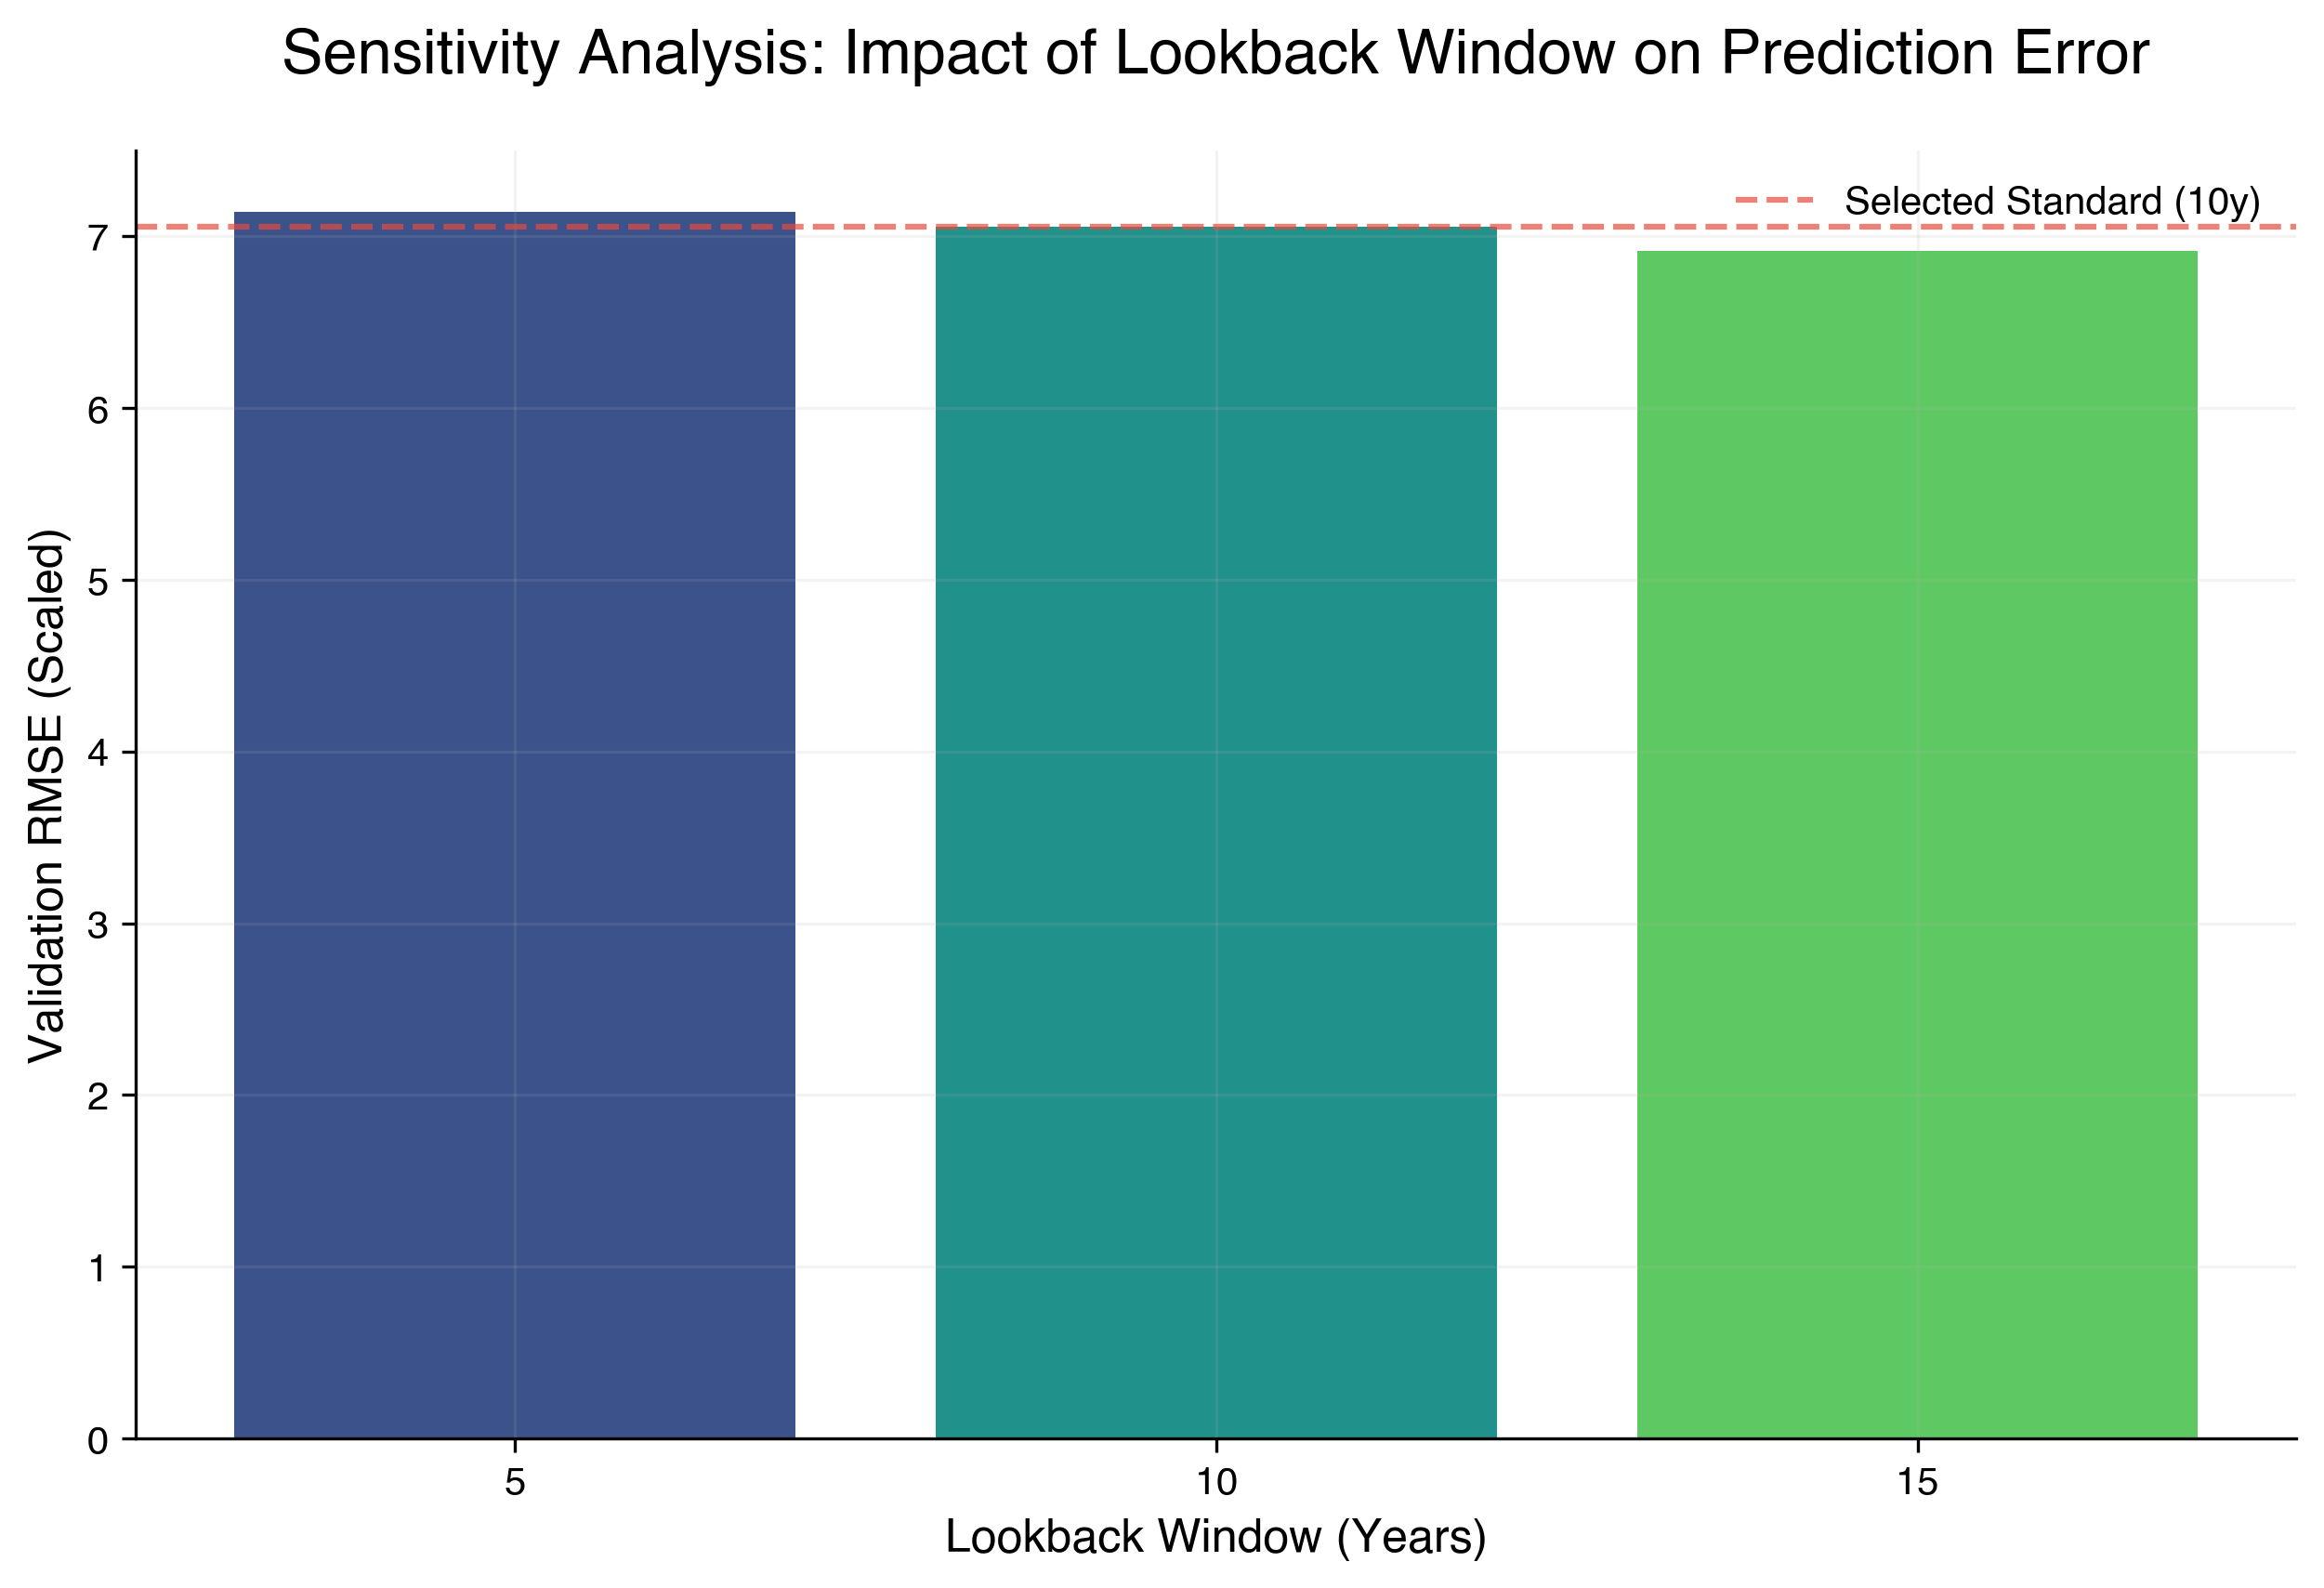


--- Sensitivity Analysis Complete ---
Fig 19 saved in: ../reports/figures/


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
import seaborn as sns
from sklearn.metrics import mean_squared_error

# 1. RESTORE DATA & SCALER (Required for Sensitivity Analysis)
# We need the original differenced features and the scaler from Notebook 03
DATA_PATH = "../data/processed/benchmarking_factors.npz"
SCALER_PATH = "../models/data_scaler.pkl"

with np.load(DATA_PATH, allow_pickle=True) as data:
    kt_global = data['kt_common']        
    kt_local_matrix = data['kt_specific_matrix'] 
    
full_features = np.column_stack([kt_global, kt_local_matrix])
diff_features = np.diff(full_features, axis=0)
n_features = diff_features.shape[1]

# Load the professional scaler
scaler = joblib.load(SCALER_PATH)
diff_scaled = scaler.transform(diff_features)

# 2. CONFIGURATION FOR COMPARISON
lookbacks_to_test = [5, 10, 15]
results_rmse = {}

print("--- Starting Sensitivity Analysis on Lookback Windows ---")

for lb in lookbacks_to_test:
    print(f"Testing Lookback: {lb} years...")
    
    # Create sequences for this specific lookback
    X_sens, y_sens = [], []
    for i in range(len(diff_scaled) - lb):
        X_sens.append(diff_scaled[i : i + lb, :])
        y_sens.append(diff_scaled[i + lb, :])
    X_sens, y_sens = np.array(X_sens), np.array(y_sens)
    
    # Split (consistent with 85% train strategy)
    train_idx = int(len(X_sens) * 0.85)
    X_tr, y_tr = X_sens[:train_idx], y_sens[:train_idx]
    X_vl, y_vl = X_sens[train_idx:], y_sens[train_idx:]
    
    # Build a simplified LSTM for rapid validation
    model_sens = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(lb, n_features)),
        tf.keras.layers.LSTM(32, return_sequences=False),
        tf.keras.layers.Dense(n_features)
    ])
    model_sens.compile(optimizer='adam', loss='mse')
    
    # Fast Training (30 epochs is enough to see the trend)
    model_sens.fit(X_tr, y_tr, epochs=30, batch_size=8, verbose=0)
    
    # Evaluate on Validation set (scaled RMSE)
    preds = model_sens.predict(X_vl, verbose=0)
    rmse = np.sqrt(mean_squared_error(y_vl, preds))
    results_rmse[lb] = rmse
    print(f"DONE. RMSE for {lb}y: {rmse:.5f}")

# 3. VISUALIZATION (Fig 19)
plt.figure(figsize=(10, 6))
# Ensure style_config aesthetics are applied
if 'set_style' in globals():
    set_style()

colors = sns.color_palette("viridis", len(lookbacks_to_test))
bars = plt.bar([str(lb) for lb in lookbacks_to_test], results_rmse.values(), color=colors)

plt.title("Sensitivity Analysis: Impact of Lookback Window on Prediction Error", pad=20)
plt.xlabel("Lookback Window (Years)")
plt.ylabel("Validation RMSE (Scaled)")

# Highlight the chosen 10y window with a specific label
plt.axhline(results_rmse[10], color='#e74c3c', linestyle='--', alpha=0.7, label='Selected Standard (10y)')
plt.legend(frameon=False)

# Save high-res for the paper
plt.savefig(f"{FIGURES_DIR}fig19_lookback_sensitivity.png", dpi=300)
plt.show()

print("\n--- Sensitivity Analysis Complete ---")
print(f"Fig 19 saved in: {FIGURES_DIR}")